In [ ]:
# o__O moments
"""
> negative coefficient means unexpected feed cost increases are associated with egg price decreases, which contradicts the basic supply chain logic.
> sotential multicollinearity bw fuel and feed prices
"""

'\n> negative coefficient means unexpected feed cost increases are associated with egg price decreases, which contradicts the basic supply chain logic.\n> sotential multicollinearity bw fuel and feed prices\n'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# front matter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import jarque_bera, kurtosis
import warnings
warnings.filterwarnings("ignore")

In [ ]:
print(pd.__version__)

2.2.2


# Load data and Hygiene

In [ ]:
# Data Load
df = pd.read_csv("/content/drive/Shareddrives/DS 440 Team 1/data/APU0000708111.csv")
df.head()
df.columns

Index(['observation_date', 'APU0000708111'], dtype='object')

In [ ]:
# hygiene
# convert to date-time format
df['observation_date'] = pd.to_datetime(df['observation_date'])
# rename cols (cuz what even is apu...)
df = df.rename(columns={
    'observation_date': 'date',
    'APU0000708111': 'price'
})

In [ ]:
# set index with monthly start
df = df.set_index('date').asfreq('MS')
# interpolate price to avoid NaN errors
df['price'] = df['price'].interpolate()
# get log price
df["log_price"] = np.log(df["price"])
df=df.dropna()

# get month for seasonality; convert qt. vars
months=df.index.month
# dummies
month_dummies = pd.get_dummies(months, prefix='m', drop_first=True).astype(int) # drop first to prevent multicollinearity-- because first is dropped, all preds are relative to jan (jan becomes baseline)
month_dummies.index = df.index
# separate into feature and response
y = df["log_price"].iloc[1:]
X = pd.concat([(month_dummies), df['log_price']], axis=1)
# adjust month_dummies for easy slicing
month_dummies = month_dummies.loc[y.index]

# Model and Preds

## Model and Predictions

### Purpose of the Modeling Framework

The goal of this modeling framework is not to maximize predictive accuracy, but to systematically separate normal egg price behavior from unexpected shocks and understand what drives those shocks.

Each model represents a layer of explanation, where additional economic mechanisms are progressively incorporated. The models are therefore used as **filters of explanation**, rather than purely predictive tools.

---

### Model Structure and Training Design

The models are estimated using different training windows due to data availability constraints, particularly for avian influenza (HPAI), which is only observed from 2008 onward.

- **v0–v2 (120-month window):** Capture baseline dynamics (persistence, seasonality, and cost effects) using a longer historical context  
- **v3–v4 (60-month window):** Incorporate additional explanatory variables (e.g., avian influenza), which are only available in a shorter, more recent time period  

This introduces a tradeoff:

- **Longer windows →** more stable parameter estimation and broader historical context  
- **Shorter windows →** richer explanatory variables but limited temporal coverage  

As a result:

> Model comparisons focus on changes in residual structure rather than direct comparisons of coefficients or overall fit.

Additionally, because models are estimated on different time windows:

> Differences in residual behavior may reflect both model specification and differences in training samples.

Thus, interpretation is conducted **within each model’s regime**, with careful consideration when comparing across models.

---

### Role of Residuals (Core of the Framework)

For each model, the residual represents:

> the portion of egg price movement that remains unexplained after accounting for known drivers

These residuals are interpreted as:

- Unexpected deviations  
- Economic shocks  
- Unmodeled structural changes  

Importantly:

> Residuals are interpreted relative to the **modern (post-2008) egg market regime**, rather than the full historical time series.

The central goal is to analyze these residuals to:

- Identify shock events  
- Measure their magnitude and duration  
- Understand how prices return to baseline  

---

### Layer-by-Layer Interpretation Strategy

Models are constructed sequentially to isolate sources of variation:

- If a spike disappears after adding a variable, that variable explains part of the shock  
- If a spike remains, it reflects unexplained or alternative mechanisms  

This allows us to distinguish between:

- **Cost-driven shocks** (e.g., feed, energy)  
- **Supply-driven shocks** (e.g., avian influenza)  

Because models are estimated on different windows, these interpretations are made:

> within the context of each model’s available data and explanatory scope.

---

### Multicollinearity Consideration

Some explanatory variables (e.g., feed costs, energy prices, and supply indicators) may be correlated.

This implies:

- Individual coefficient estimates may be unstable  
- Attribution at the variable level may be ambiguous  

However, this does not invalidate the framework, because:

> The objective is not precise coefficient interpretation, but how the inclusion of variables changes residual structure.

In other words:

> We care about what gets explained, not how each coefficient behaves.

---

### Clean Residual Concept

A “clean” residual is one that shows:

- Minimal structure  
- Fewer large spikes  
- No systematic patterns  

As more relevant variables are added:

- Some predictable variation is removed  
- Residuals may become less structured but not necessarily smaller  
- Remaining spikes become more interpretable  

Importantly:

> Residual variance does not always decrease, especially when smoother components are removed and more irregular, shock-driven variation remains.

---

### Connection to Variance Decomposition

This framework decomposes egg price dynamics into components:

- Persistence (AR(1))  
- Seasonality  
- Input costs (feed, energy)  
- Supply shocks (avian influenza)  
- Residual (unexplained variation)  

The goal is to understand how much variation each layer removes, rather than to estimate exact parameter values.

---

### Key Takeaway

The purpose of this framework is to progressively strip away known sources of variation so that the remaining residuals isolate true economic shocks.

An important principle is:

> A good model is not one that eliminates all deviations, but one that clearly defines what remains unexplained.

These remaining deviations provide insight into:

- The nature of shocks  
- Their underlying causes  
- Their build-up and recovery dynamics  

Finally, this analysis focuses on the **modern egg market (post-2008)**, where volatility, supply disruptions, and structural changes are more pronounced.

An important aspect of this framework is that deviations from the model (residuals) represent unexpected price movements. The goal is not for the model to perfectly fit the data, but to capture normal behavior so that remaining deviations can be interpreted as shocks.

## v0

In [ ]:
"""
v0: model persistence
assumption: stable \phi to avoid refitting at every iteration
training window: 10 years (60 months)
=> we use a 10-year training window to capture sufficient price history while avoiding the early low-price regime that would bias the coefficient estimates
predictive residuals
"""

'\nv0: model persistence\nassumption: stable \\phi to avoid refitting at every iteration\ntraining window: 10 years (60 months)\n=> we use a 10-year training window to capture sufficient price history while avoiding the early low-price regime that would bias the coefficient estimates\npredictive residuals\n'

In [ ]:
train_start_date = pd.Timestamp('2008-01-01')
train_end_date   = pd.Timestamp('2013-01-01')

train_mask = (y.index >= train_start_date) & (y.index < train_end_date)
test_mask  = y.index >= train_end_date

v0 = AutoReg(y[train_mask], lags=1).fit()
phi = v0.params[1]
preds, res = [], []
for t_date in y[test_mask].index:
    const = v0.params[0]
    pred = const + phi * y.loc[y.index[y.index.get_loc(t_date)-1]]
    residual = y.loc[t_date] - pred
    preds.append(pred)
    res.append(residual)

preds = pd.Series(preds, index=y[test_mask].index)
res   = pd.Series(res,   index=y[test_mask].index)

In [ ]:
# get rolling z score
rolling_std= res.rolling(window=12, min_periods=12).std() # w/o min periods first 11 vals become NaN (can't find std)
rolling_mean=res.rolling(window=12, min_periods=12).mean() # need this to normalise z score
z_score_rolling=(res-rolling_mean)/rolling_std # to ensure z scores dont get too affected by the upward drift of residuals

In [ ]:
# defined shocks as |z|>=2, extreme shocks where |z|>=3
shocks = np.abs(z_score_rolling) >= 2

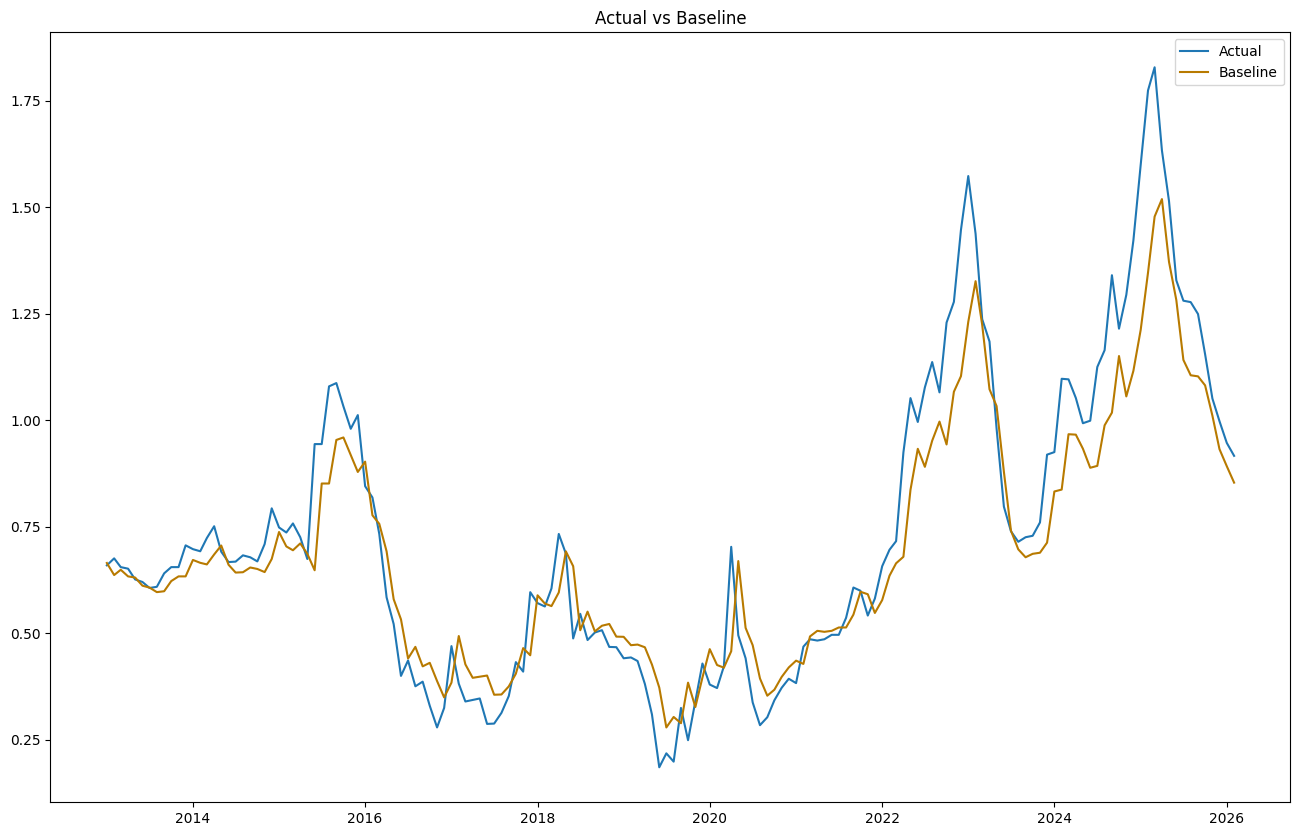

In [ ]:
# actual v pred
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.plot(preds, label='Baseline', color="#B87A00")
plt.legend()
plt.title("Actual vs Baseline")
plt.show()

### What is the baseline model?

The baseline model represents expected egg price behavior under normal conditions. It includes:

- Persistence (prices depend on the previous month)  
- Seasonality (predictable monthly patterns)  

Importantly, the baseline excludes external drivers such as feed costs, energy prices, and avian influenza. As a result, it captures how prices evolve when no major disruptions occur.

This baseline is estimated within the **modern (post-2008) egg market regime**, meaning it reflects normal behavior in a period characterized by higher volatility and more frequent disruptions.

The purpose of the baseline is not to perfectly predict prices, but to establish a reference point for identifying abnormal behavior.

> Deviations from the baseline correspond to residuals and represent economic shocks.

---

### How does the baseline differ from other model versions?

The baseline (v0) defines normal price dynamics, while later model versions (v2–v4) attempt to explain deviations from that baseline.

- v0: Includes only persistence and tends to misclassify seasonal patterns as shocks  
- v1 : Adds seasonality and captures normal behavior  
- v2: Adds feed cost shocks to explain part of the deviations  
- v3: Adds energy costs  
- v4: Adds avian influenza (supply-side shocks)  

Thus, the baseline answers:

> “What should prices look like under normal conditions?”

While the extended models answer:

> “Why do prices deviate from that expectation?”

### Interpretation: Actual vs Baseline Egg Prices

This plot compares observed egg prices (actual) to a model-based baseline representing expected price behavior under normal production conditions.

The baseline captures predictable dynamics such as persistence and seasonality, and therefore reflects how prices would evolve in the absence of major disruptions.

A key observation is that the baseline tracks the actual series closely during stable periods, indicating that most month-to-month price movements are predictable.

However, large deviations between the actual and baseline lines represent **residuals**, which correspond to shock episodes—periods where prices behave in ways that cannot be explained by normal production dynamics.

---

### Spikes and Their Causes

The most prominent spikes occur when prices rise sharply above the baseline. These are consistent with major supply disruptions, particularly:

- **2014–2015 spike:** consistent with an avian influenza (HPAI) outbreak that reduced the number of laying hens and constrained supply  
- **2022–2023 spike:** reflects a combination of HPAI outbreaks, elevated feed costs, and broader supply chain disruptions  

In both cases, the baseline fails to capture the magnitude of the increase because these events represent unexpected shocks to production capacity, not normal fluctuations.

---

### Build-Up Dynamics (How Spikes Form)

A consistent pattern across spikes is that prices build up gradually over several months rather than jumping instantly.

This reflects the underlying production mechanism:

- Flock losses occur over time  
- Egg production declines progressively  
- Supply tightens, causing prices to increase step-by-step  

This gradual build-up suggests that egg price shocks are cumulative supply disruptions rather than single-period events.

---

### Die-Down Dynamics (How Prices Recover)

After reaching a peak, prices tend to fall more quickly than they rise.

This faster die-down reflects market adjustment mechanisms:

- Producers begin rebuilding flocks  
- Imports and substitution effects stabilize supply  
- Demand adjusts in response to high prices  

This creates an asymmetry in price behavior:

> slow increases, but faster corrections.

---

### Economic Interpretation

This plot demonstrates that egg prices are governed by three key forces:

- **Persistence (AR(1))**  
  Prices depend heavily on previous values, explaining why the baseline tracks normal movements  

- **Seasonality (minor effect)**  
  Predictable monthly patterns exist but are relatively small  

- **Supply and Cost Shocks (dominant driver of spikes)**  
  Major deviations from the baseline reflect disruptions such as:  
  - Avian influenza (biological supply shocks)  
  - Feed cost increases (input cost shocks)  
  - Energy and supply chain pressures  

---

### Key Takeaway

The most important insight from this plot is that egg price volatility is **shock-driven rather than trend-driven**.

- Normal price movements are well explained by persistence and seasonality  
- Large price spikes occur when production is disrupted  
- These shocks build gradually and resolve more quickly  

Overall, this confirms that egg prices behave as a **supply-constrained system**, where disruptions in production capacity drive the most significant price movements.

 the baseline tracks the actual series closely, lags by about one month as expected from AR(1), and the big shocks show up clearly as gaps between the two lines.

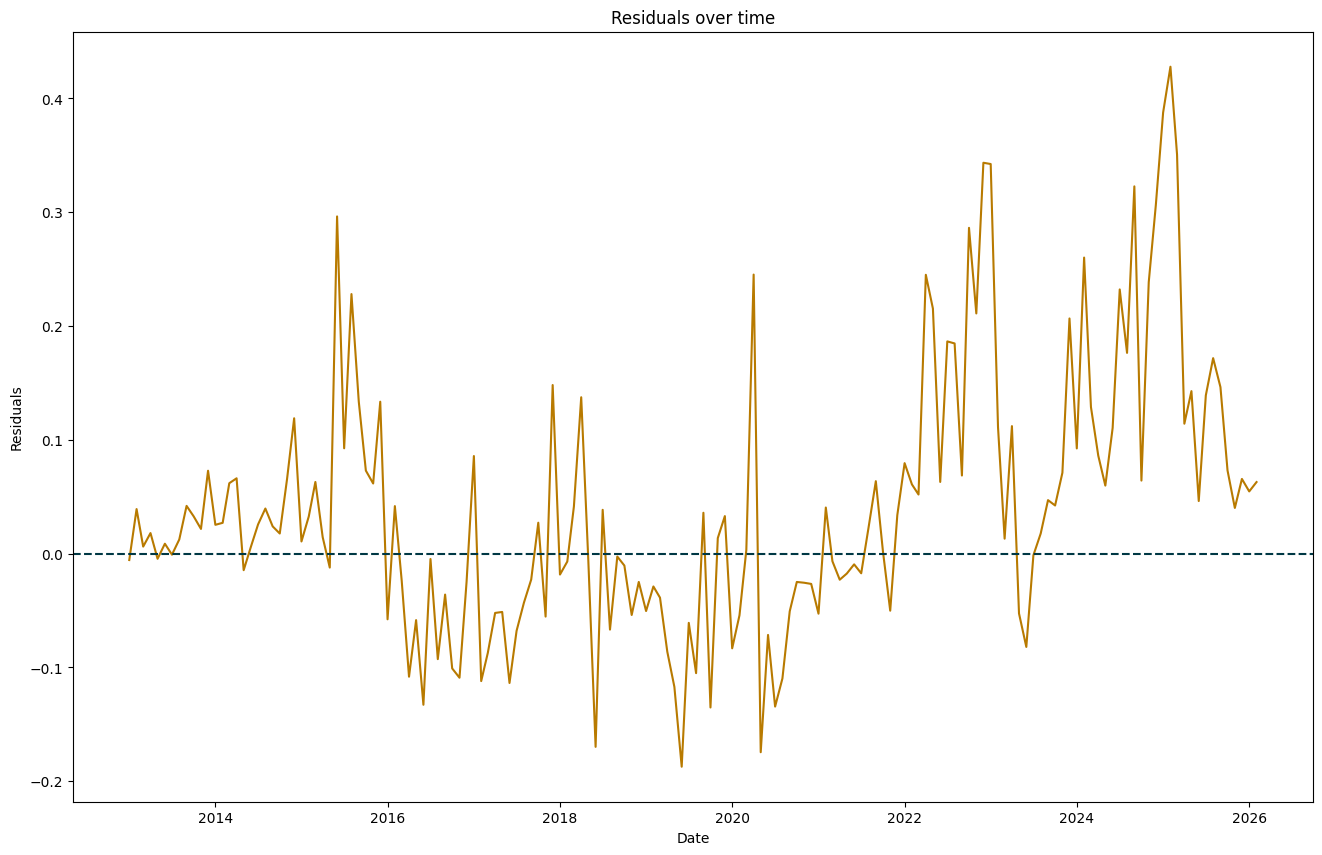

In [ ]:
# residuals over time
plt.figure(figsize=(16,10))
plt.plot(res, color="#B87A00")
plt.axhline(0, linestyle='--', color="#003844")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("Residuals over time")
plt.show()

### Interpretation: Residuals Over Time (Unexpected Price Movements)

This plot shows the residuals from the baseline model, defined as the difference between actual egg prices and the predicted baseline. Since the baseline captures normal dynamics (persistence and seasonality), the residuals represent unexpected deviations, or shocks.

Importantly:

> These residuals are interpreted relative to the modern (post-2008) egg market regime, meaning they reflect deviations from expected behavior in a higher-volatility environment.

---

### Direction of Shocks: Predominantly Upward

A key observation is that most residuals are positive, meaning that egg prices are more often higher than expected than lower within this period.

This indicates that:

- Price shocks are predominantly upward  
- The egg market is primarily affected by supply shortages rather than demand collapses  

This is consistent with real-world mechanisms such as:

- Avian influenza (HPAI) reducing flock size  
- Input cost increases (feed, energy)  

---

### Magnitude of Shocks Over Time

Residuals increase in magnitude across the sample period:

- Earlier periods (post-2008) show relatively smaller deviations  
- Later periods (especially post-2015 and post-2020) show larger spikes  

This suggests that:

> Volatility is elevated in more recent periods within this sample, with larger and more pronounced disruptions.

---

### Clustering and Persistence of Shocks

Residual spikes tend to cluster together rather than occur in isolation. Periods such as 2014–2015 and 2022–2024 show sustained positive residuals over multiple months.

This indicates that:

- Shocks are not single-period events  
- They evolve into multi-month episodes  

This reflects real production dynamics:

- Flock losses and supply disruptions occur gradually  
- Recovery takes time, leading to prolonged deviations from expected prices  

---

### Interpretation of Negative Residuals

While less frequent, negative residuals indicate periods where prices fall below expected levels. These may reflect:

- Rapid recovery after a supply shock  
- Temporary oversupply  
- Demand adjustments following high-price periods  

---

### Key Takeaway

The residuals isolate the true shock component of egg prices relative to the baseline model.

The pattern observed in this plot shows that:

- Egg price shocks are primarily upward and supply-driven  
- Shocks are larger in recent periods within the sample  
- Shocks persist across multiple months rather than occurring instantaneously  

Overall, this confirms that egg prices are driven by episodic supply disruptions, rather than smooth or purely trend-based behavior.

Residuals are roughly centered around zero across the full period, meaning the model isn't systematically over or under-predicting
The variance is small and stable pre-2008, then grows noticeably after, with the largest spikes clustering around 2015 and 2022-23. This heteroskedasticity tells us egg price behavior shifted regimes — the post-2015 world is fundamentally more volatile than before, and a single static standard deviation would be a poor shock threshold.

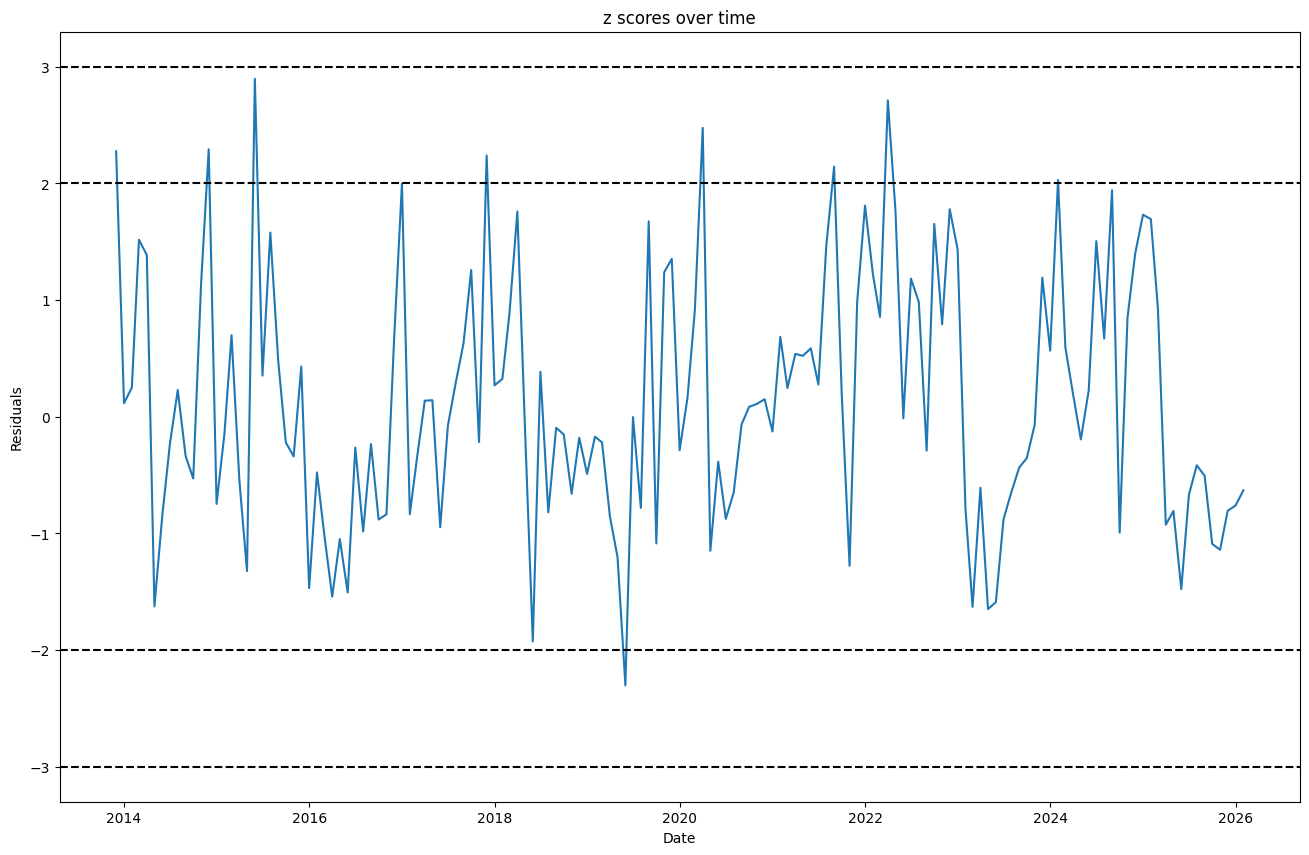

In [ ]:
# z_score over time
plt.figure(figsize=(16,10))
plt.plot(z_score_rolling)
plt.axhline(2, linestyle='--', color='black')
plt.axhline(-2, linestyle='--', color='black')
plt.axhline(3, linestyle='--', color='black')
plt.axhline(-3, linestyle='--', color='black')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("z scores over time")
plt.show()

### Interpretation: Standardized Residuals (Z-Scores)

This plot standardizes the residuals by scaling them relative to recent volatility, allowing us to identify unusually large deviations in egg prices.

Because these are standardized residuals:

> Z-scores measure how extreme a deviation is relative to expected variation in the modern (post-2008) egg market regime.

A z-score measures how extreme a deviation is:

- |z| < 2 → normal fluctuation  
- |z| ≥ 2 → statistically significant shock  
- |z| ≥ 3 → extreme shock  

---

### Identifying Meaningful Shocks

Most observations fall within the range of -2 to 2, indicating that the majority of price movements are consistent with normal variation.

However, several spikes exceed the ±2 threshold, marking periods where prices deviate significantly from expected behavior.

These correspond to residuals that are unusually large relative to typical volatility and therefore represent **meaningful economic shock events**.

---

### Direction of Shocks

The largest z-score spikes are predominantly positive, meaning prices are significantly higher than expected.

This reinforces a key finding:

> Egg price shocks are primarily upward, driven by supply shortages rather than demand declines.

---

### Temporal Patterns

Large z-score spikes are more frequent and more extreme in recent periods within the sample (especially post-2020).

This suggests that:

> The egg market exhibits elevated volatility in recent years, with more frequent and more severe disruptions.

---

### Key Takeaway

The z-score transformation provides a formal, statistical definition of a shock by standardizing residuals relative to expected variability.

It allows us to:

- Distinguish between normal price fluctuations and meaningful disruptions  
- Identify periods of significant deviation from expected behavior  

These identified shocks are then used to define and analyze shock episodes in the next stage of the analysis.


Subtracting the rolling mean is fixing the symptom (biased z-scores) rather than the cause (model under-predicting due to drift). You're essentially de-meaning the residuals locally, which will center your z-scores but it also means you'll miss slow-moving sustained price increases as shocks — because the rolling mean will absorb them.
Think about 2022. Prices rose sharply and stayed high for many months. If your rolling mean is tracking that sustained rise, it'll subtract it out and the z-scores won't spike as dramatically. You'd be dampening exactly the kind of shock you want to detect.


tl;dr:

 known issue: rolling mean subtraction centers z-scores but may dampen sustained shocks like 2022. Consider adding explicit trend term to model instead

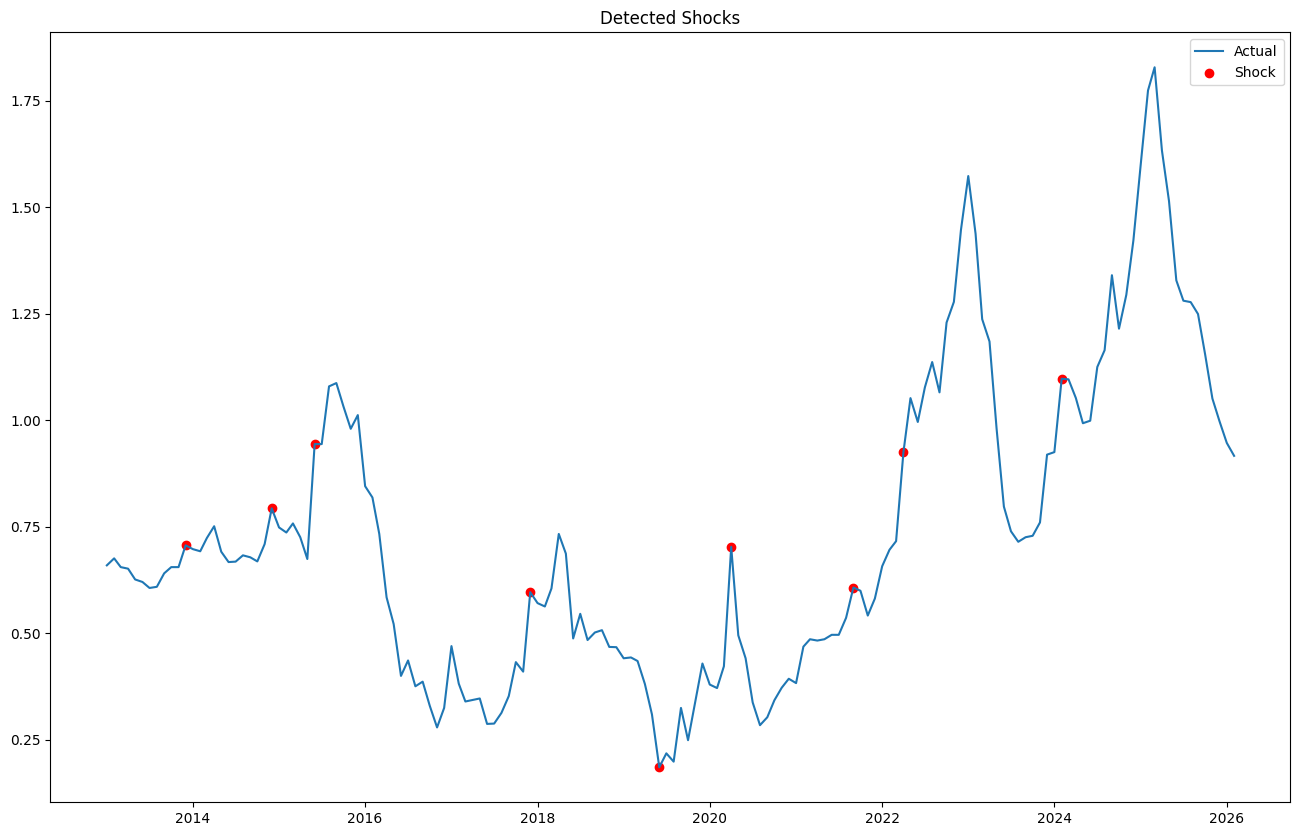

In [ ]:
# detected shocks
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.scatter(y[test_mask].index[shocks], y[test_mask][shocks], color='red', label='Shock')

plt.legend()
plt.title("Detected Shocks")
plt.show()

### Interpretation: Detected Shock Periods

This plot highlights months where the standardized residual exceeds the shock threshold (|z| ≥ 2), marking statistically significant deviations from expected egg price behavior.

Each red point represents a period in which prices are unusually high relative to the baseline model, meaning the residual is large compared to typical variation in the modern (post-2008) regime.

---

### Clustering of Shocks

The detected shocks are not randomly distributed over time. Instead, they appear in clusters, forming distinct episodes such as:

- 2014–2015 (avian influenza outbreak)  
- 2022–2024 (recent supply disruptions)  

This indicates that:

> Egg price shocks persist over multiple months rather than occurring as isolated events.

---

### Relationship to Price Movements

The detected shocks align closely with the steep upward movements in the price series. They tend to occur during periods of rapid price increases, rather than during stable or declining periods.

This suggests that:

> Shocks are associated with the build-up phase of price spikes, where supply constraints are intensifying.

---

### Economic Interpretation

These shock periods are consistent with real-world disruptions in egg production, including:

- Avian influenza reducing flock size  
- Increases in feed and input costs  
- Supply chain pressures  

The persistence of shocks reflects the time required for:

- Production capacity to decline (during disruption)  
- Supply to recover (after the shock)  

---

### Key Takeaway

The detected shocks provide a clear, data-driven identification of when egg prices behave abnormally relative to the baseline model.

These periods represent supply-driven disruptions and confirm that:

> Egg price volatility is driven by episodic shocks rather than continuous or smooth fluctuations.

In [ ]:
# summary table SINCE 2013
start=pd.Timestamp('2013-01-01')
summary=pd.DataFrame({
    'Model Name': ['v0'],
    'STD': [res[start:].std()],
    'Mean': [res[start:].mean()],
    'Shocks': [shocks[start:].sum()]
})

## v1

In [ ]:
"""
v1: model persistence + seasonality
eqn: pred = const + φ · y[t-1] + β_m · month_dummy +eps
training window: 10 years (60 months)
=> we use a 10-year training window to capture sufficient price history while avoiding the early low-price regime that would bias the coefficient estimates
predictive residuals
expectation: if March is always a bit lower than average, v0 would flag that as a negative residual every year. V1 accounts for it so it disappears from the residuals. What's left should be genuinely unexpected movements
"""

"\nv1: model persistence + seasonality\neqn: pred = const + φ · y[t-1] + β_m · month_dummy +eps\ntraining window: 10 years (60 months)\n=> we use a 10-year training window to capture sufficient price history while avoiding the early low-price regime that would bias the coefficient estimates\npredictive residuals\nexpectation: if March is always a bit lower than average, v0 would flag that as a negative residual every year. V1 accounts for it so it disappears from the residuals. What's left should be genuinely unexpected movements\n"

In [ ]:
v1 = AutoReg(y[train_mask], lags=1, exog=month_dummies[train_mask]).fit()
phi = v1.params[1]
preds1, res1 = [], []
for t_date in y[test_mask].index:
    const = v1.params[0]
    month = t_date.month
    seasonal = v1.params[f'm_{month}'] if month != 1 else 0
    pred = const + phi * y.loc[y.index[y.index.get_loc(t_date)-1]] + seasonal
    residual = y.loc[t_date] - pred
    preds1.append(pred)
    res1.append(residual)
# convert the lists to series
preds1 = pd.Series(preds1, index=y[test_mask].index)
res1   = pd.Series(res1,   index=y[test_mask].index)


January is the baseline — it's the dropped dummy. So there's no m_1 in the params. When it's January, all the month dummies are 0, so the seasonal contribution is just 0. The prediction for January is simply const + φ·y[t-1].
For April, m_4 = -0.019 — so prices in April are expected to be about 1.9% lower than January, all else equal.

In [ ]:
# get rolling z score
rolling_std= res1.rolling(window=12, min_periods=12).std() # w/o min periods first 11 vals become NaN (can't find std)
rolling_mean=res1.rolling(window=12, min_periods=12).mean() # need this to normalise z score
z_score_rolling1=(res1-rolling_mean)/rolling_std # to ensure z scores dont get too affected by the upward drift of residuals

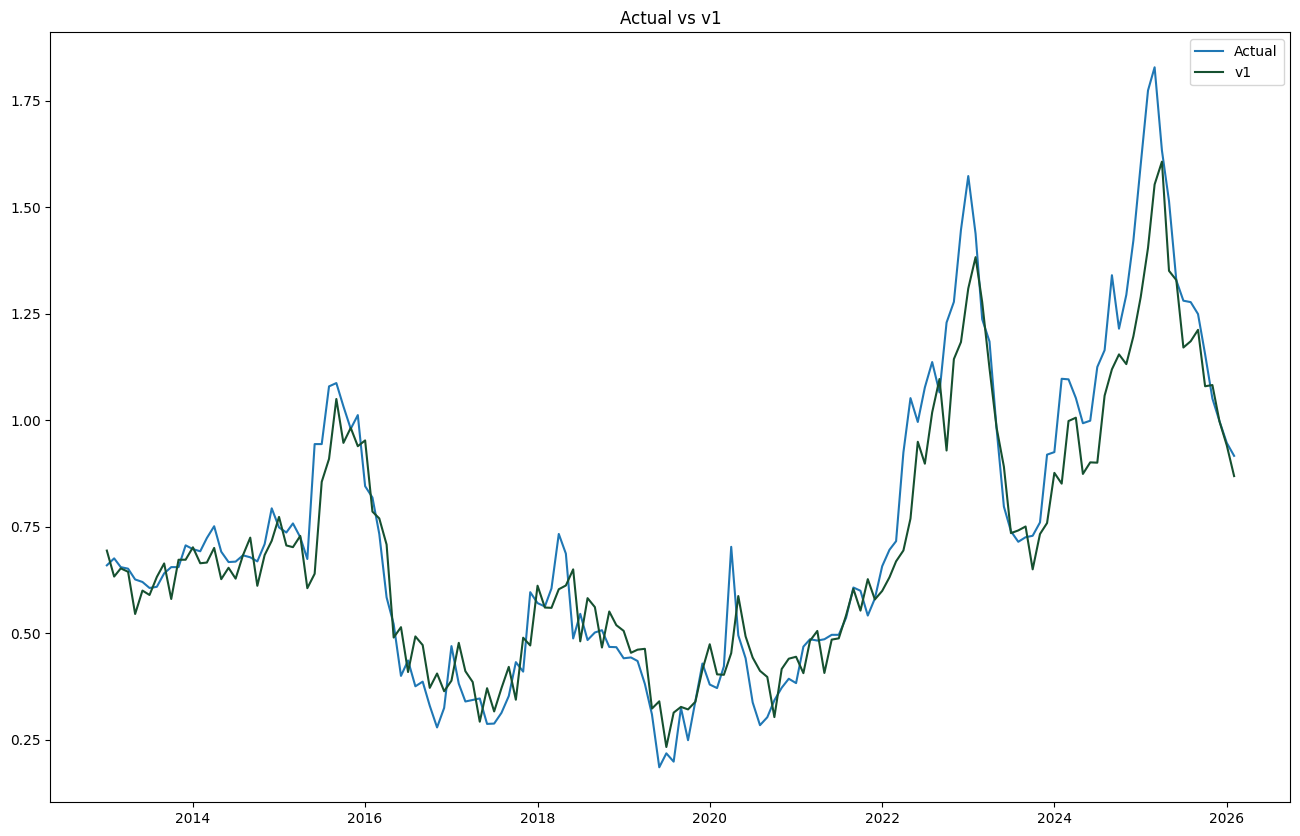

In [ ]:
# actual v pred
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.plot(preds1, label='v1', color="#165030")
plt.legend()
plt.title("Actual vs v1")
plt.show()

### What is the v1 model?

The v1 model represents expected egg price behavior under normal conditions, incorporating:

- Persistence (AR(1)): prices depend on previous values  
- Seasonality: predictable monthly patterns driven by production cycles and demand  

It does not include external drivers such as feed costs, energy, or avian influenza. As a result, it reflects how prices evolve in the absence of major disruptions.

Importantly, this model is estimated within the **modern (post-2008) egg market regime**, meaning it reflects normal behavior in a higher-volatility environment.

---

### How does the v1 model differ from other model versions?

- v0: includes only persistence and may misclassify seasonal patterns as shocks  
- v1: adds seasonality and serves as the baseline for normal behavior  
- v2–v4: extend v1 by incorporating real-world drivers (feed, energy, avian influenza) to explain deviations  

Thus:

> v1 defines what prices should look like  
> Later models explain why prices deviate  

---

### Interpretation of the Plot

The v1 model closely tracks actual prices during stable periods, indicating that most movements are predictable.

However, large deviations occur during shock events, where actual prices rise significantly above the model.

> These deviations represent residuals — unexpected movements not explained by persistence or seasonality.

---

### Spikes and Their Causes

Major spikes occur in:

- 2014–2015: consistent with avian influenza reducing flock size  
- 2022–2024: repeated avian influenza outbreaks combined with elevated input costs  

The v1 model underpredicts these periods because it does not include these external drivers.

---

### Build-Up Dynamics (How Spikes Form)

Price spikes consistently build over multiple months rather than appearing instantly.

This occurs because:

- Supply disruptions (e.g., flock loss) accumulate over time  
- Production declines gradually  
- Prices adjust step-by-step as supply tightens  

The v1 model captures part of this increase due to persistence, but the actual series rises more steeply due to additional shock effects.

---

### Detailed Shock Dynamics: 2022–2024 Episode

The most recent spike shows a multi-phase structure:

- Initial build-up (2021–early 2022): gradual increase due to rising costs and early supply pressure  
- First major spike (mid–late 2022): sharp increase consistent with avian influenza outbreaks  
- Rapid die-down (early 2023): prices fall as supply begins to recover  
- Second spike (late 2023–2024): renewed disruptions and incomplete recovery  

This reflects a system where:

> recovery is incomplete before new shocks occur  

---

### Die-Down Dynamics (Recovery)

Across major spikes, prices tend to fall faster than they rise.

This is driven by:

- Supply recovery through flock rebuilding  
- Market corrections and demand adjustment  

This creates asymmetric behavior:

> slow buildup, faster decline  

---

### Economic Interpretation

Egg prices are driven by:

- Persistence (normal behavior)  
- Seasonality (minor effect)  
- Supply and cost shocks (dominant during spikes)  

The largest deviations are associated with disruptions to production capacity.

---

### Key Takeaway

The v1 model establishes a clear baseline for normal price behavior.

While it explains most movements, it fails during disruptions, highlighting true shocks.

These shocks:

- Build gradually  
- Resolve more quickly  
- Can reoccur before full recovery  

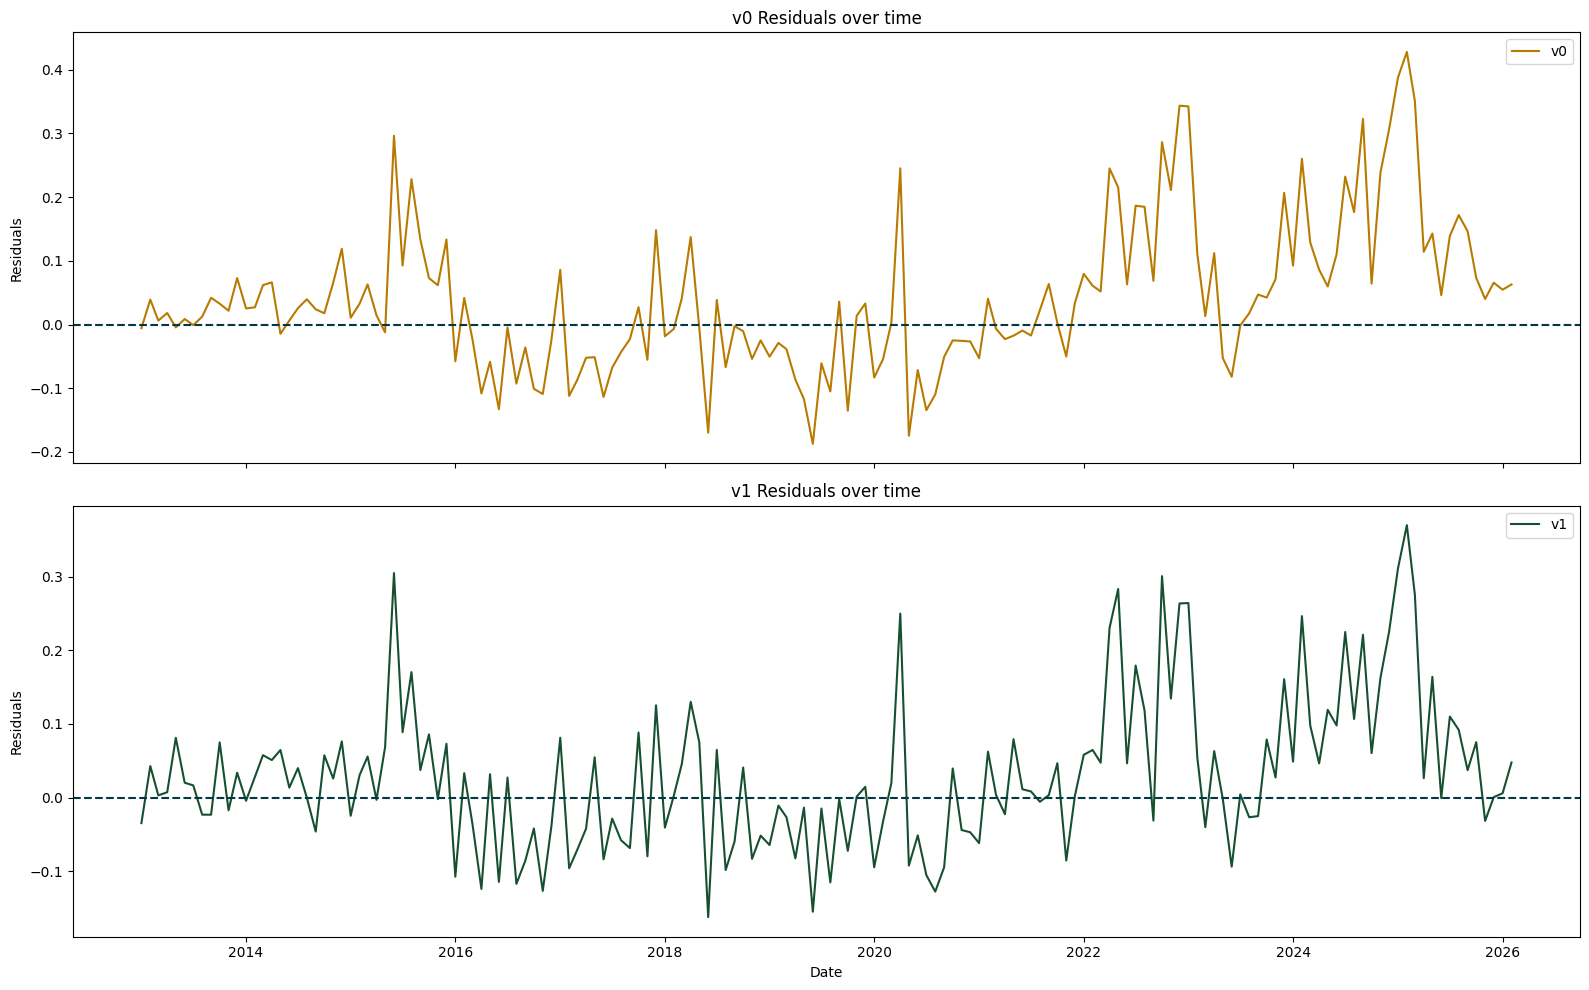

In [ ]:
# residuals over time-- v0 and v1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax1.plot(res, color="#B87A00", label='v0')
ax1.axhline(0, linestyle='--', color="#003844")
ax1.set_ylabel("Residuals")
ax1.set_title("v0 Residuals over time")
ax1.legend()

ax2.plot(res1, color="#165030", label='v1')
ax2.axhline(0, linestyle='--', color="#003844")
ax2.set_ylabel("Residuals")
ax2.set_title("v1 Residuals over time")
ax2.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation: Residuals Over Time (v1 Model)

The v1 residuals represent deviations from a model that includes both persistence (AR(1)) and seasonality.

These residuals isolate price movements that cannot be explained by normal dynamics within the modern (post-2008) regime.

---

### Improvement over v0

Compared to v0:

- Residual variance decreases (STD: 0.116 → 0.102)  
- Residuals are more concentrated around zero  
- Noise is reduced  

This indicates that:

> Some variation previously identified as shocks in v0 was actually predictable seasonal behavior.

---

### Interpretation of Remaining Residuals

The remaining residuals now more clearly represent true economic shocks:

- Positive → prices higher than expected → supply shortages or cost pressures  
- Negative → prices lower than expected → recovery or temporary oversupply  

Large residual spikes remain in:

- 2014–2015  
- 2022–2024  

---

### Clustering and Persistence

Residuals cluster in specific periods, indicating:

- Shocks persist over multiple months  
- They are not isolated events  

This reflects real-world dynamics:

- Supply disruptions unfold gradually  
- Recovery takes time  

---

### Key Insight

By removing seasonality, v1 produces a cleaner residual signal.

> The remaining structure reflects true unexpected shocks rather than predictable variation.

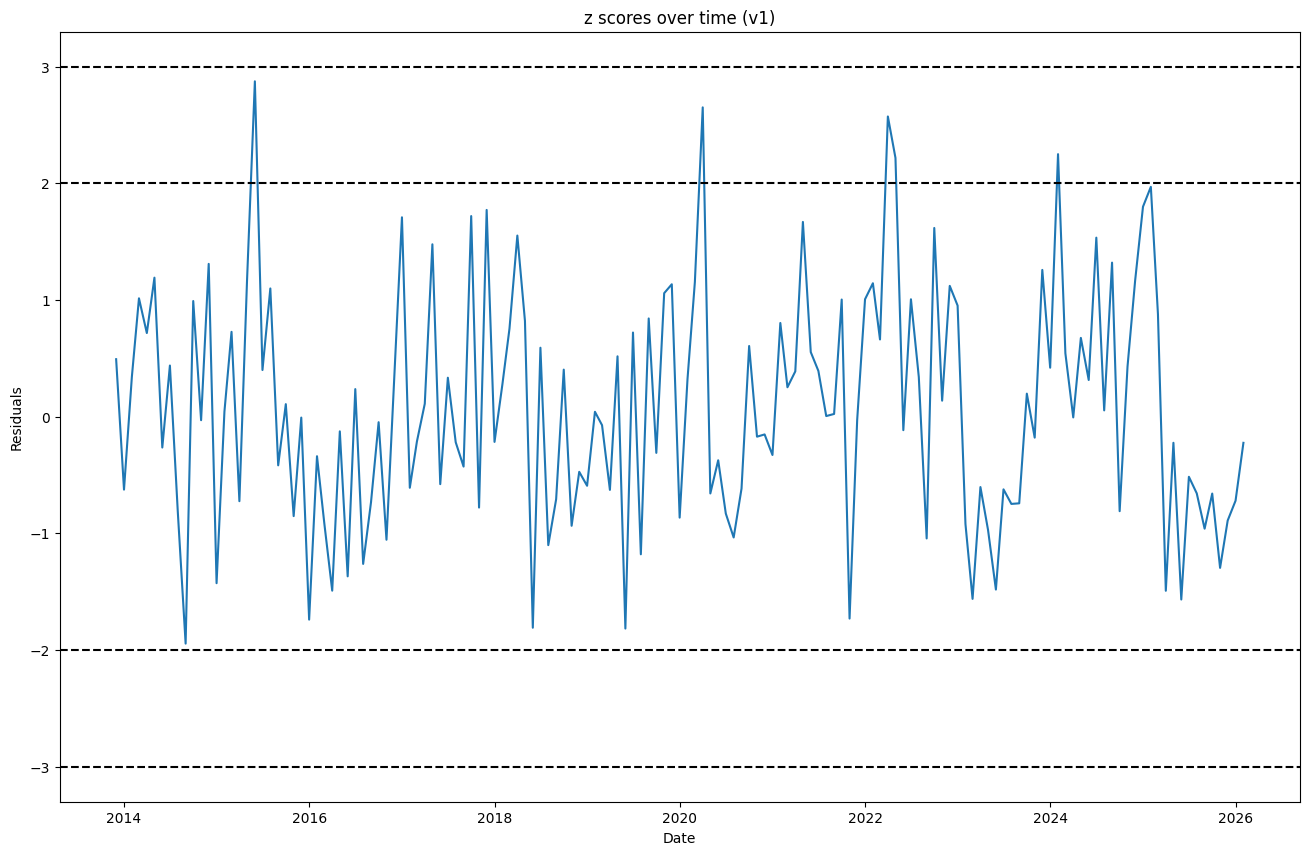

In [ ]:
shocks1 = np.abs(z_score_rolling1) >= 2
plt.figure(figsize=(16,10))
plt.plot(z_score_rolling1)
plt.axhline(2, linestyle='--', color='black')
plt.axhline(-2, linestyle='--', color='black')
plt.axhline(3, linestyle='--', color='black')
plt.axhline(-3, linestyle='--', color='black')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("z scores over time (v1)")
plt.show()

### Interpretation: Standardized Residuals (Z-Scores, v1 Model)

The z-score transformation standardizes residuals relative to recent volatility in the modern regime.

---

### Improvement over v0

- Fewer observations exceed ±2  
- Shocks decrease (9 → 5)  
- Extreme values are more concentrated in disruption periods  

This indicates:

> Some extreme values in v0 were driven by seasonality rather than true shocks.

---

### Interpretation of Shock Thresholds

- |z| < 2 → normal variation  
- |z| ≥ 2 → significant shock  
- |z| ≥ 3 → extreme shock  

---

### Temporal Patterns

Spikes remain concentrated in:

- 2014–2015  
- 2022–2024  

---

### Key Insight

Removing seasonality produces more reliable z-scores.

> Remaining extremes represent genuine economic disruptions.

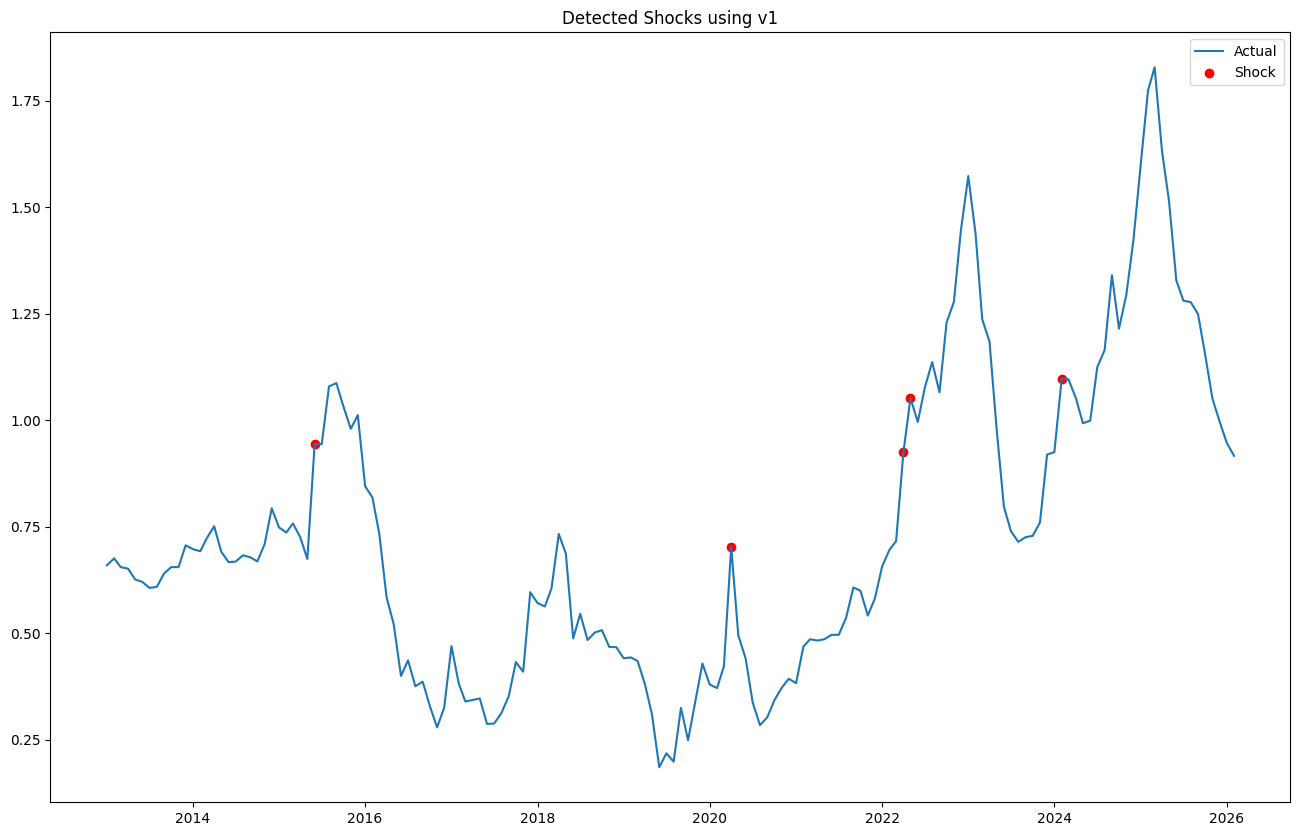

In [ ]:
# detected shocks
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.scatter(y[test_mask].index[shocks1], y[test_mask][shocks1], color='red', label='Shock')

plt.legend()
plt.title("Detected Shocks using v1")
plt.show()

### Interpretation: Detected Shocks (v1 Model)

This plot identifies periods where |z| ≥ 2, marking statistically significant deviations.

---

### Improvement over v0

- Shocks decrease (9 → 5)  
- False positives are removed  

This indicates:

> v1 isolates fewer but more meaningful shock events.

---

### Interpretation of Detected Shocks

Detected shocks align with:

- 2014–2015 (avian influenza)  
- 2022–2024 (repeated disruptions and cost pressures)  

They are:

- Clustered  
- Persistent  
- Associated with production disruptions  

---

### Relationship to Price Dynamics

Shocks occur during rapid price increases:

> They align with the build-up phase of supply constraints.

---

### Key Insight

Compared to v0, v1 provides more precise shock detection.

> It removes predictable variation and isolates true disruptions.

In [ ]:
# add to summary table
start=pd.Timestamp('2013-01-01')
summary.loc[len(summary)] = ['v1', res1[start:].std(), res1[start:].mean(), shocks1[start:].sum()]
summary

,Model Name,STD,Mean,Shocks
0,v0,0.116124,0.041299,9
1,v1,0.102191,0.030556,5


### Overall Transition from v0 to v1

The transition from v0 to v1 represents a critical improvement.

By adding seasonality:

- Predictable patterns are removed  
- Residuals become cleaner  
- Shock detection becomes more accurate  

This demonstrates:

> Not all deviations are shocks — some are predictable components.

As a result:

> v1 provides a more reliable baseline for identifying true economic disruptions.

## v2

In [ ]:
"""
v2: model persistence + seasonality + feed price
eqn: pred = const + φ · y[t-1] + β_m · month_dummy + β_p · feed_price
data: using poultry feed data=> holistic + optimal lag k=1 so cleaner to interpret
transformation: Feed PPI is an index (not a dollar price) that has also drifted upward over time and likely has increasing variance so use log(feed price)
> stabilize variance, make changes interpretable as proportional rather than absolute.
"""

'\nv2: model persistence + seasonality + feed price\neqn: pred = const + φ · y[t-1] + β_m · month_dummy + β_p · feed_price\ndata: using poultry feed data=> holistic + optimal lag k=1 so cleaner to interpret\ntransformation: Feed PPI is an index (not a dollar price) that has also drifted upward over time and likely has increasing variance so use log(feed price)\n> stabilize variance, make changes interpretable as proportional rather than absolute.\n'

In [ ]:
# load feed; change date format
feed_res = pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/feed_ppi_log.csv', parse_dates=['date'])
feed_res = feed_res.set_index('date').asfreq('MS')

In [ ]:
feed_res.head()

,feed_ppi_log
date,
1986-12-01,4.605170
1987-01-01,4.597138
1987-02-01,4.594109
1987-03-01,4.577799
1987-04-01,4.594109


In [ ]:
# get dummies for feed res + concat w egg prices
full_exog = pd.concat([month_dummies, feed_res['feed_ppi_log'].shift(1)], axis=1)
full_exog = full_exog.loc[y.index]  # trim to egg price dates only

print("NaNs after alignment:", full_exog['feed_ppi_log'].isnull().sum())
print("first valid:", full_exog['feed_ppi_log'].first_valid_index())

NaNs after alignment: 83
first valid: 1987-01-01 00:00:00


In [ ]:
print(full_exog['feed_ppi_log'].isnull().sum(), "total NaNs")
print("first valid index:", full_exog['feed_ppi_log'].first_valid_index())
print(full_exog['feed_ppi_log'].iloc[118:128])  # peek around the boundary

83 total NaNs
first valid index: 1987-01-01 00:00:00
date
1989-12-01    4.804021
1990-01-01    4.802380
1990-02-01    4.806477
1990-03-01    4.779963
1990-04-01    4.765587
1990-05-01    4.794964
1990-06-01    4.837868
1990-07-01    4.821893
1990-08-01    4.847332
1990-09-01    4.801559
Freq: MS, Name: feed_ppi_log, dtype: float64


In [ ]:
# first valid date + 5 years
train_start_date = pd.Timestamp('2008-01-01')
train_end_date   = train_start_date + pd.DateOffset(years=5)

train_mask = (y.index >= train_start_date) & (y.index < train_end_date)
test_mask  = y.index >= train_end_date

v2 = AutoReg(y[train_mask], lags=1, exog=full_exog[train_mask]).fit()
phi = v2.params[1]
preds2, res2 = [], []
for t_date in y[test_mask].index:
    const    = v2.params[0]
    month    = t_date.month
    seasonal = v2.params[f'm_{month}'] if month != 1 else 0
    feed     = v2.params['feed_ppi_log']
    pred     = const + phi * y.loc[y.index[y.index.get_loc(t_date)-1]] + seasonal + feed * full_exog.loc[t_date, 'feed_ppi_log']
    residual = y.loc[t_date] - pred
    preds2.append(pred)
    res2.append(residual)

preds2 = pd.Series(preds2, index=y[test_mask].index)
res2   = pd.Series(res2,   index=y[test_mask].index)

In [ ]:
# get rolling z score
rolling_std= res2.rolling(window=12, min_periods=12).std() # w/o min periods first 11 vals become NaN (can't find std)
rolling_mean=res2.rolling(window=12, min_periods=12).mean() # need this to normalise z score
z_score_rolling2=(res2-rolling_mean)/rolling_std # to ensure z scores dont get too affected by the upward drift of residuals

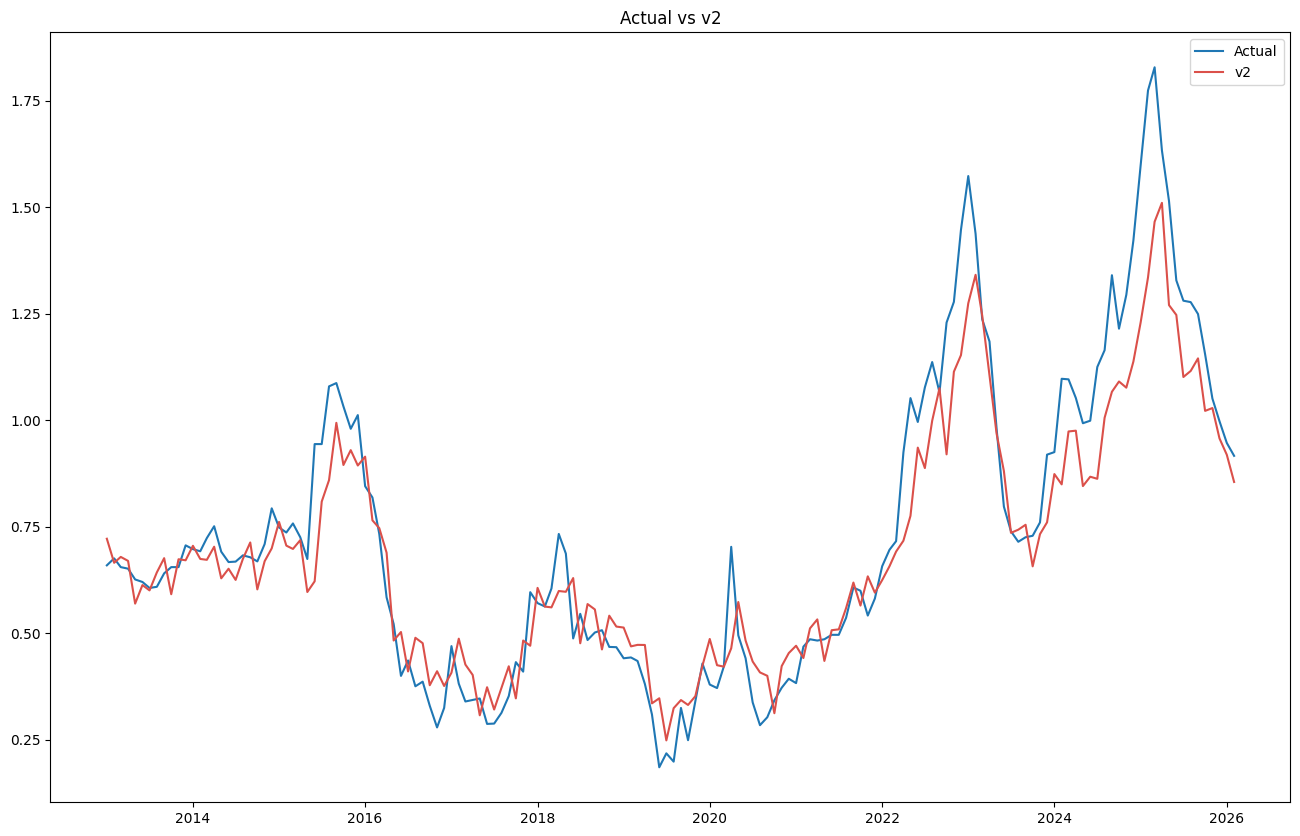

In [ ]:
# actual v pred
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.plot(preds2, label='v2', color="#DB504A")
plt.legend()
plt.title("Actual vs v2")
plt.show()

### What is the v2 model?

The v2 model extends the baseline (v1) by incorporating feed cost dynamics, in addition to:

- Persistence (AR(1))  
- Seasonality  
- Feed Price Index (Feed PPI)  

Feed costs are a major input in egg production, meaning changes in feed prices directly affect production costs and, ultimately, egg prices.

Like v1, this model is estimated within the **modern (post-2008) regime**, but now includes an important economic driver of price variation.

---

### How does the v2 model differ from other model versions?

- v0: persistence only  
- v1: persistence + seasonality (baseline behavior)  
- v2: adds feed costs (input cost channel)  
- v3–v4: add additional drivers (energy, avian influenza)  

Thus:

> v2 explains part of *why* prices deviate from the baseline by incorporating cost-side pressures.

---

### Interpretation of the Plot

Compared to v1, the v2 model tracks the actual series slightly differently, particularly during periods of rising prices.

In some episodes, the model moves closer to the actual series, suggesting that:

> feed costs explain part of the observed price variation.

However, large gaps between actual and predicted values still remain during major spikes.

---

### Spikes and Their Causes

Key spike periods:

- 2014–2015: still largely unexplained → consistent with supply shock (avian influenza)  
- 2022–2024: partially explained → combination of feed costs and supply disruptions  

This indicates:

> feed costs contribute to price increases, but do not fully explain major spikes.

---

### Build-Up Dynamics (How Spikes Form)

The v2 model captures slightly more of the gradual increase during buildup phases compared to v1.

This suggests:

- Rising feed costs contribute to early-stage price increases  
- Cost pressures accumulate before major supply disruptions occur  

However:

> the steepest increases are still not captured, indicating additional mechanisms (e.g., supply shocks).

---

### Die-Down Dynamics (Recovery)

During recovery periods, v2 behaves similarly to v1:

- Prices fall faster than they rise  
- The model partially tracks the decline  

Feed costs play a role, but:

> recovery dynamics are still largely driven by supply-side adjustment.

---

### Economic Interpretation

The v2 model introduces a **cost-driven channel**:

- Feed prices increase production costs  
- Producers pass costs into egg prices  
- This contributes to gradual upward pressure  

However:

- Feed costs alone cannot explain extreme spikes  
- Supply shocks remain the dominant driver of large deviations  

---

### Key Takeaway

The v2 model shows that:

- Feed costs explain part of normal and moderate price variation  
- They contribute to the buildup of price increases  
- But they do not explain extreme spikes  

> This indicates that egg price shocks are not purely cost-driven, and require additional supply-side explanations.

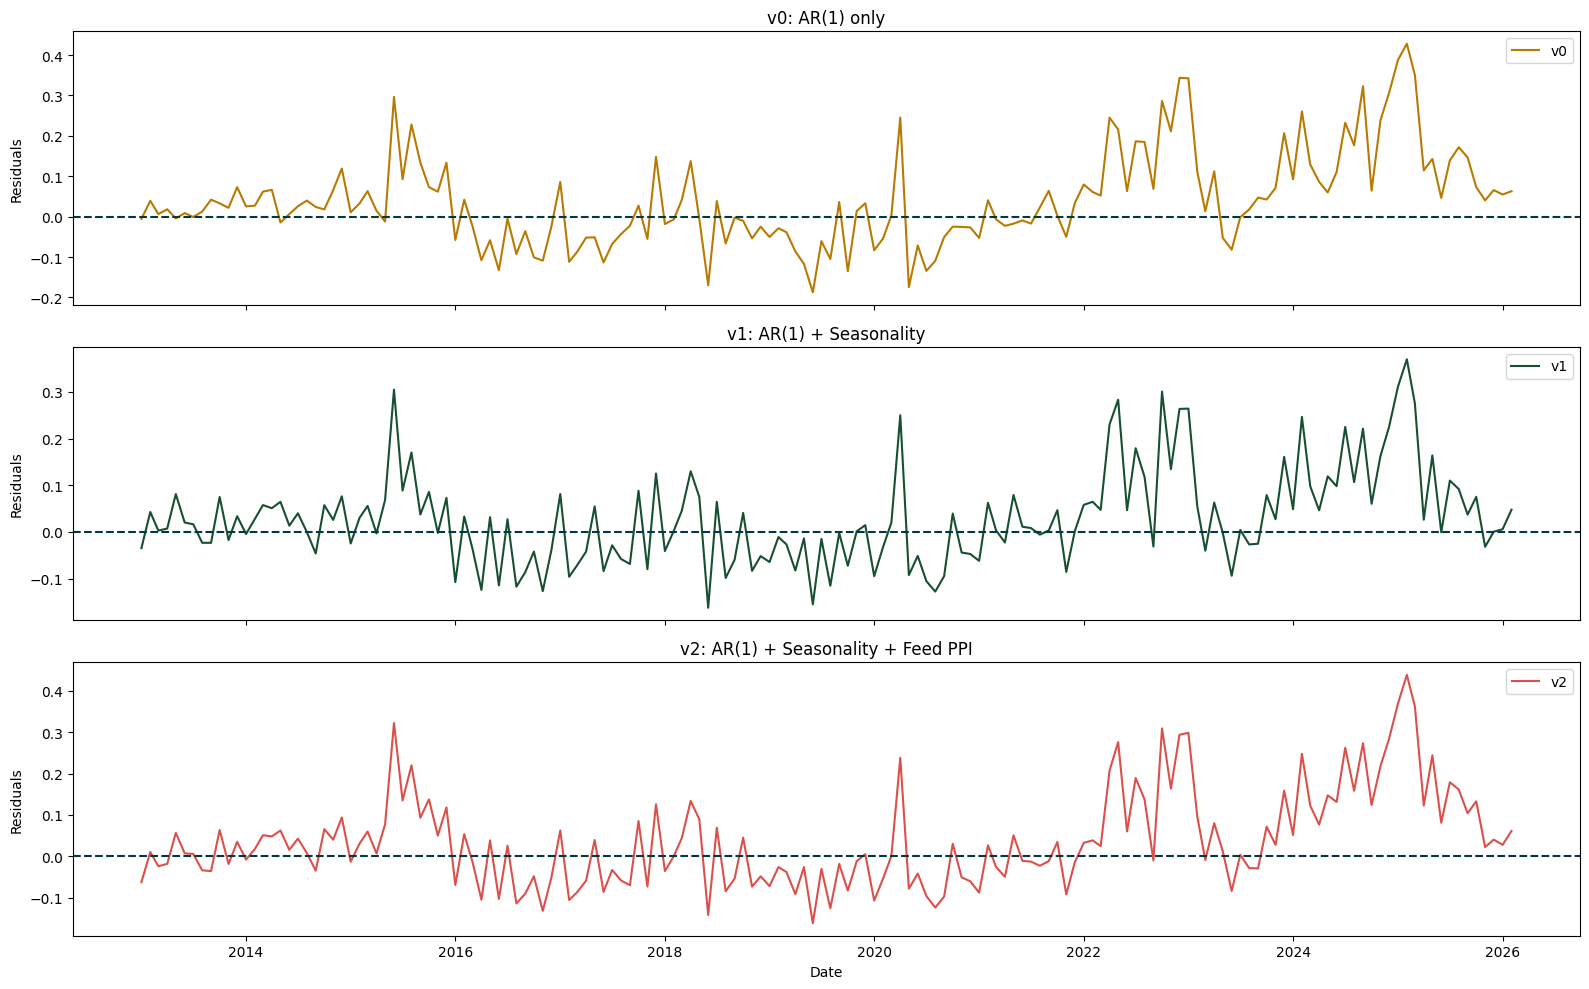

In [ ]:
# residuals over time-- v0, v1, v2 starting at the common start of  Jan 2000
common_start = res2.index[0]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax1.plot(res.loc[common_start:], color="#B87A00", label='v0')
ax1.axhline(0, linestyle='--', color="#003844")
ax1.set_title("v0: AR(1) only")
ax1.set_ylabel("Residuals")
ax1.legend()

ax2.plot(res1.loc[common_start:], color="#165030", label='v1')
ax2.axhline(0, linestyle='--', color="#003844")
ax2.set_title("v1: AR(1) + Seasonality")
ax2.set_ylabel("Residuals")
ax2.legend()

ax3.plot(res2, color="#DB504A", label='v2')
ax3.axhline(0, linestyle='--', color="#003844")
ax3.set_title("v2: AR(1) + Seasonality + Feed PPI")
ax3.set_ylabel("Residuals")
ax3.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation: Residuals Over Time (v2 Model)

The v2 residuals represent deviations from a model that includes:

- Persistence  
- Seasonality  
- Feed costs  

These residuals isolate variation not explained by normal dynamics or input cost pressures.

---

### Comparison to v1

- STD increases (0.102 → 0.115)  
- Mean residual increases slightly  
- Number of shocks remains unchanged (5)  

This indicates:

> adding feed costs does not uniformly reduce unexplained variation.

---

### Interpretation of This Result

This is **VERY important**:

- Feed costs explain some movements  
- But introduce additional variability due to correlation with other predictors  

This reflects:

> multicollinearity between economic variables (e.g., feed, energy, broader inflation).

---

### Interpretation of Remaining Residuals

Residuals still show large spikes during:

- 2014–2015  
- 2022–2024  

These represent:

- Supply-driven shocks not captured by feed costs  
- Structural disruptions in production capacity  

---

### Clustering and Persistence

Residual clustering remains:

- Shocks persist over multiple months  
- Patterns are similar to v1  

This indicates:

> feed costs do not eliminate shock persistence.

---

### Key Insight

The v2 residuals demonstrate that:

- Cost variables explain part of variation  
- But do not significantly clean the residual structure  

> True shocks remain, particularly those driven by supply disruptions.

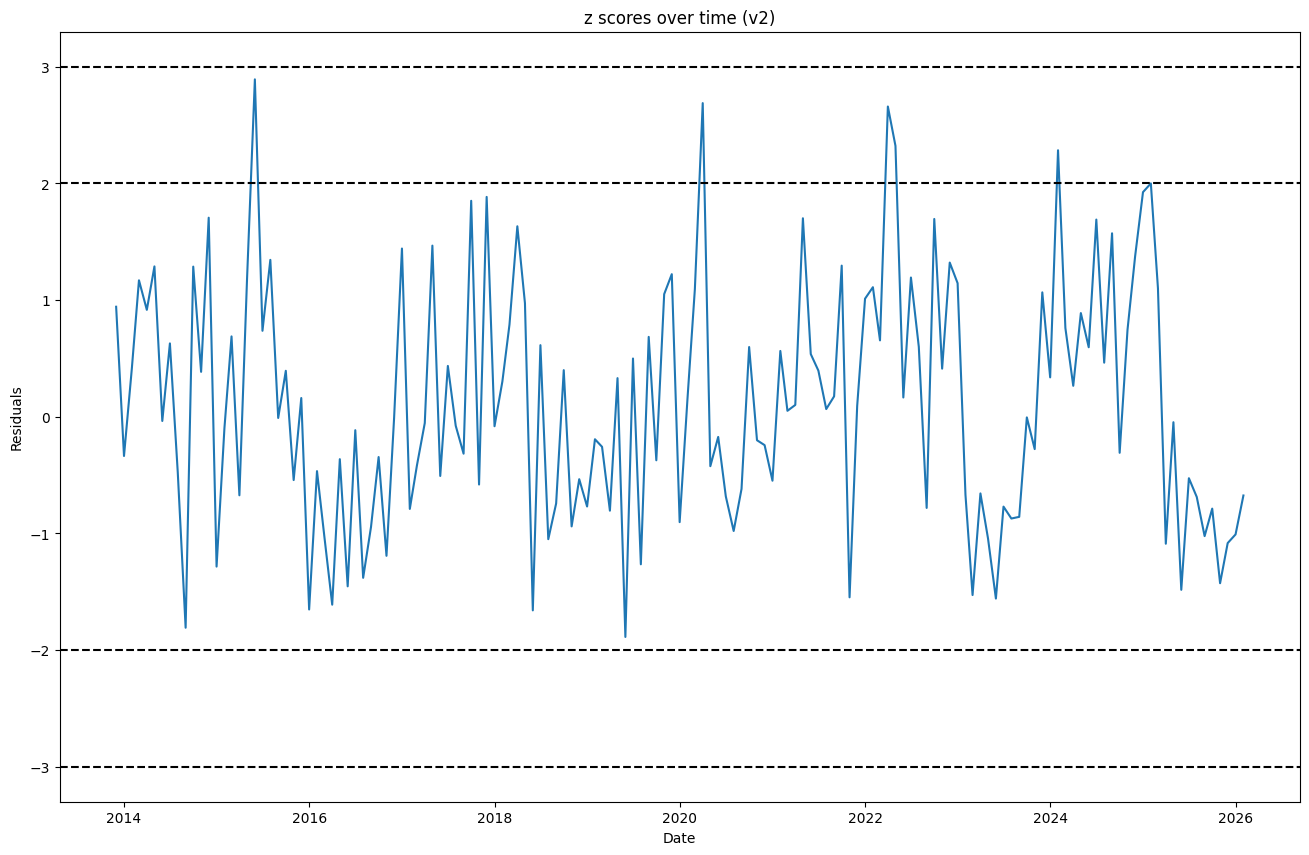

In [ ]:
# zscore over time
shocks2 = np.abs(z_score_rolling2) >= 2
plt.figure(figsize=(16,10))
plt.plot(z_score_rolling2)
plt.axhline(2, linestyle='--', color='black')
plt.axhline(-2, linestyle='--', color='black')
plt.axhline(3, linestyle='--', color='black')
plt.axhline(-3, linestyle='--', color='black')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("z scores over time (v2)")
plt.show()

### Interpretation: Standardized Residuals (Z-Scores, v2 Model)

Z-scores standardize residuals relative to volatility.

---

### Comparison to v1

- Number of shocks remains the same (5)  
- Distribution of z-scores is similar  

This indicates:

> feed costs do not materially change which events are classified as shocks.

---

### Interpretation of Shock Thresholds

- |z| < 2 → normal variation  
- |z| ≥ 2 → significant shock  

Major spikes still exceed thresholds during:

- 2014–2015  
- 2022–2024  

---

### Temporal Patterns

No major reduction in extreme values.

This suggests:

> extreme events are not primarily driven by feed costs.

---

### Key Insight

The z-score results confirm:

> feed costs do not eliminate large shocks — they only explain part of the variation leading up to them.

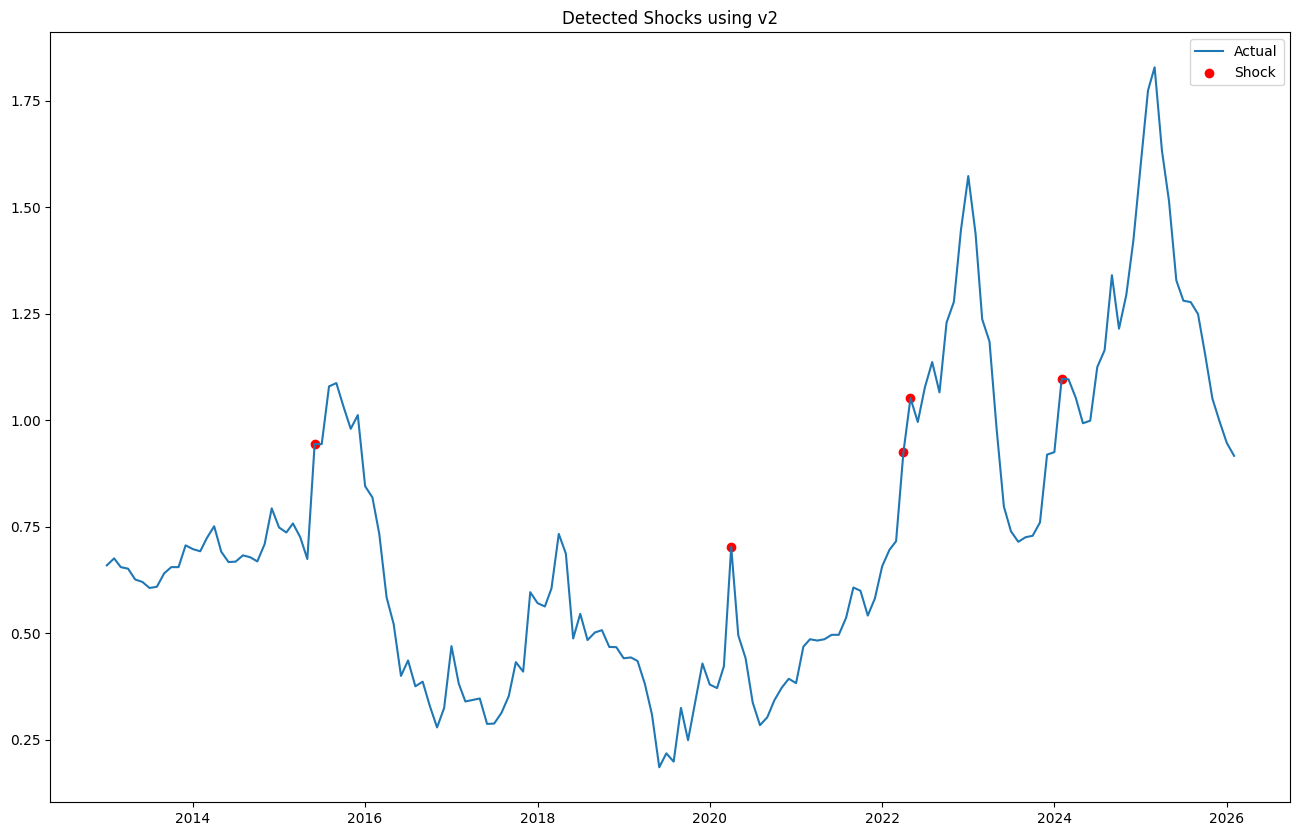

In [ ]:
# detected shocks
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.scatter(y[test_mask].index[shocks2], y[test_mask][shocks2], color='red', label='Shock')

plt.legend()
plt.title("Detected Shocks using v2")
plt.show()

### Interpretation: Detected Shocks (v2 Model)

This plot identifies periods where |z| ≥ 2.

---

### Comparison to v1

- Number of shocks remains unchanged (5)  
- Timing of shocks is nearly identical  

This indicates:

> feed costs do not change when shocks occur.

---

### Interpretation of Detected Shocks

Detected shocks remain concentrated in:

- 2014–2015  
- 2022–2024  

These align with major production disruptions.

---

### Relationship to Price Dynamics

Shocks still occur during rapid price increases.

This confirms:

> the most significant deviations are tied to supply constraints rather than cost changes.

---

### Key Insight

The v2 model improves economic interpretation, but not shock detection.

> It explains part of the *why*, but does not change the *when* of shocks.

In [ ]:
# add to summary table
start=pd.Timestamp('2013-01-01')
summary.loc[len(summary)] = ['v2', res2[start:].std(), res2[start:].mean(), shocks2[start:].sum()]
summary

,Model Name,STD,Mean,Shocks
0,v0,0.116124,0.041299,9
1,v1,0.102191,0.030556,5
2,v2,0.114896,0.038897,5


### Overall Transition from v1 to v2

The transition from v1 to v2 introduces feed costs as a key economic driver.

This reveals an important insight:

- Feed costs contribute to price increases  
- But do not explain extreme deviations  

Key observations:

- Residual variance does not decrease  
- Shock count remains unchanged  
- Major spikes persist  

This demonstrates:

> Egg price shocks are not purely cost-driven.

Instead:

- Cost pressures contribute to buildup  
- Supply disruptions drive extreme spikes  

---

### Core Takeaway

The v2 model shows that:

> Explaining price variation requires both cost-side and supply-side factors.

Feed costs are an important component, but:

> they are not sufficient to explain the largest shocks in egg prices.

## v3

In [ ]:
"""
v3: model persistence + seasonality + feed price + num_deaths
eqn: pred (log price) = const + φ · y[t-1] + β_m · month_dummy + β_p · log_feed_price + β_d · log_deaths
training window: 5 yrs (2008-2013)
data: using log(layer_losses + 1)=> log to make reln more linear and coeffs more stable; +1 to prevent log(0) error

"""

'\nv3: model persistence + seasonality + feed price + num_deaths\neqn: pred (log price) = const + φ · y[t-1] + β_m · month_dummy + β_p · log_feed_price + β_d · log_deaths\ntraining window: 5 yrs (2008-2013)\ndata: using log(layer_losses + 1)=> log to make reln more linear and coeffs more stable; +1 to prevent log(0) error\n\n'

In [ ]:
# load data for flu; change date format
layer_losses = pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/flu_severity.csv', parse_dates=['date'])
layer_losses = layer_losses.set_index('date').asfreq('MS')
layer_losses = layer_losses.interpolate()
layer_losses.head()

,layer_losses_head,outbreak_dummy,severity_score,hpai_birds_affected,log_layer_losses_plus1,log_hpai_birds_affected_plus1
date,,,,,,
1980-01-01,0.0,0.0,0.0,0.0,0.0,0.0
1980-02-01,0.0,0.0,0.0,0.0,0.0,0.0
1980-03-01,0.0,0.0,0.0,0.0,0.0,0.0
1980-04-01,0.0,0.0,0.0,0.0,0.0,0.0
1980-05-01,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# concat w egg prices
full_exog3 = pd.concat([month_dummies, feed_res['feed_ppi_log'].shift(1), layer_losses['log_layer_losses_plus1'].shift(1)], axis=1)
full_exog3 = full_exog3.loc[y.index]  # trim to egg price dates only

print("NaNs after alignment:", full_exog3['log_layer_losses_plus1'].isnull().sum())
print("first valid:", full_exog3['log_layer_losses_plus1'].first_valid_index())

NaNs after alignment: 0
first valid: 1980-02-01 00:00:00


In [ ]:
# first valid date w layer losses + 5 years
train_start_date = pd.Timestamp('2008-01-01')
train_end_date   = train_start_date + pd.DateOffset(years=5)

train_mask = (y.index >= train_start_date) & (y.index < train_end_date)
test_mask  = y.index >= train_end_date

v3 = AutoReg(y[train_mask], lags=1, exog=full_exog3[train_mask]).fit()
phi = v3.params[1]
preds3, res3 = [], []
for t_date in y[test_mask].index:
    const    = v3.params[0]
    month    = t_date.month
    seasonal = v3.params[f'm_{month}'] if month != 1 else 0
    feed     = v3.params['feed_ppi_log']
    losses   = v3.params['log_layer_losses_plus1']
    pred     = const + phi * y.loc[y.index[y.index.get_loc(t_date)-1]] + seasonal + feed * full_exog3.loc[t_date, 'feed_ppi_log'] + losses * full_exog3.loc[t_date, 'log_layer_losses_plus1']
    residual = y.loc[t_date] - pred
    preds3.append(pred)
    res3.append(residual)

preds3 = pd.Series(preds3, index=y[test_mask].index)
res3  = pd.Series(res3,   index=y[test_mask].index)

during 2008-2013 training, layer losses are mostly at baseline levels with little HPAI activity. The coefficient is being estimated on near-zero variation, so it's picking up noise rather than a real relationship. "even after controlling for feed costs and layer mortality baseline, these episodes remain anomalous."

In [ ]:
# get rolling z score
rolling_std= res3.rolling(window=12, min_periods=12).std() # w/o min periods first 11 vals become NaN (can't find std)
rolling_mean=res3.rolling(window=12, min_periods=12).mean() # need this to normalise z score
z_score_rolling3=(res3-rolling_mean)/rolling_std # to ensure z scores dont get too affected by the upward drift of residuals

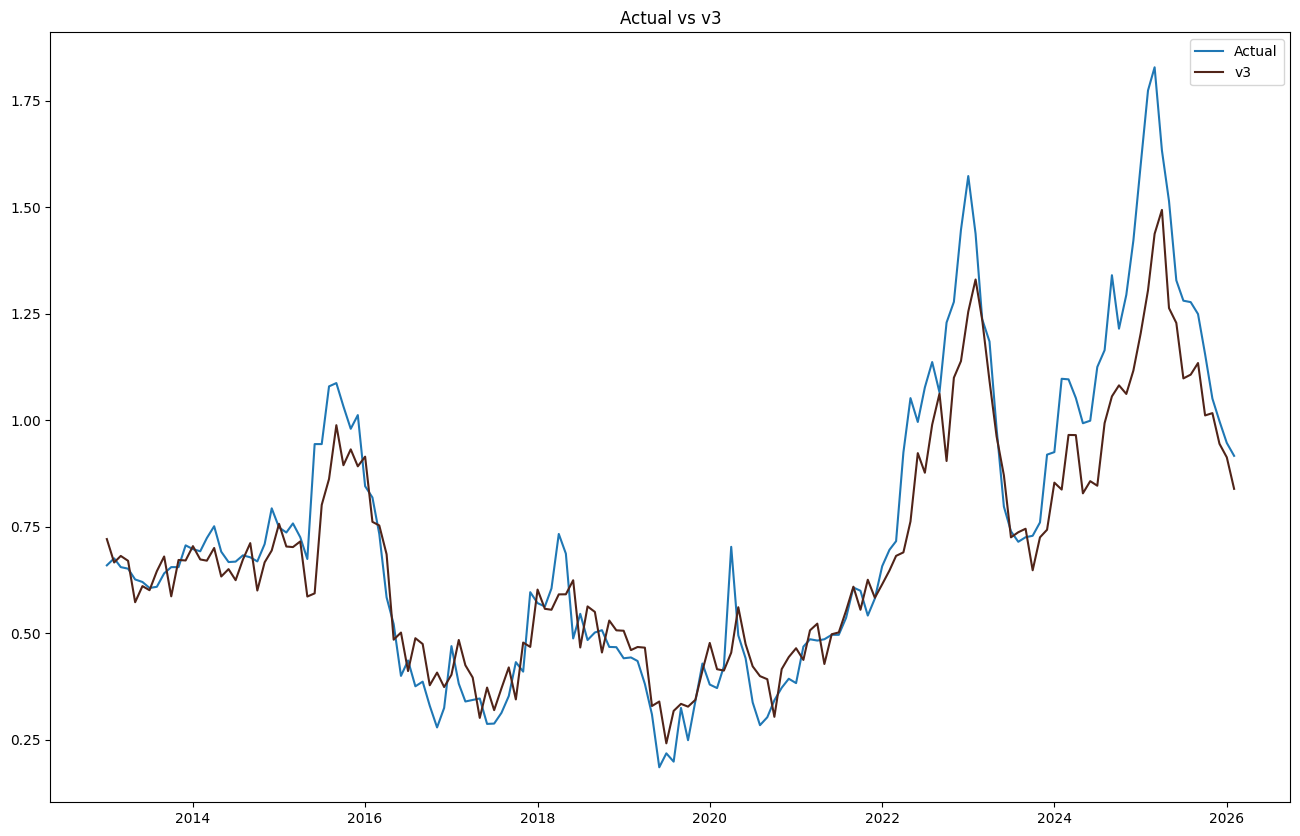

In [ ]:
# actual v pred
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.plot(preds3, label='v3', color="#502419")
plt.legend()
plt.title("Actual vs v3")
plt.show()

### What is the v3 model?

The v3 model extends v2 by incorporating supply-side disruptions through layer losses (a proxy for avian influenza impact), in addition to:

- Persistence (AR(1))  
- Seasonality  
- Feed Price Index (Feed PPI)  
- Layer losses (supply shock proxy)  

Layer losses directly capture reductions in egg-laying hens, which constrain supply and are a primary driver of price spikes.

---

### How does the v3 model differ from other model versions?

- v0: persistence only  
- v1: adds seasonality (baseline behavior)  
- v2: adds feed costs (cost-side pressure)  
- v3: adds supply shocks (layer losses)  

Thus:

> v3 is the first model that explicitly captures **production capacity disruptions**, not just cost pressures.

---

### Interpretation of the Plot

Compared to v2, the v3 model more closely tracks the actual series during major spike periods.

In particular:

- The gap between actual and predicted prices is reduced during large spikes  
- The model captures more of the sharp upward movements  

This indicates:

> supply-side variables explain a significant portion of previously unexplained price variation.

---

### Spikes and Their Causes

Key periods:

- 2014–2015: improved tracking → explained by avian influenza-related flock losses  
- 2022–2024: better alignment → reflects repeated supply disruptions  

Unlike v2:

> v3 begins to capture the **magnitude** of these spikes, not just their direction.

---

### Build-Up Dynamics (How Spikes Form)

The v3 model better captures the buildup phase:

- Gradual increases in prices now align more closely with the model  
- This reflects the accumulation of flock losses over time  

This suggests:

> price increases are directly linked to declining production capacity.

---

### Die-Down Dynamics (Recovery)

During recovery:

- The model still lags slightly behind the sharp decline  
- This reflects the difficulty of modeling rapid recovery dynamics  

However:

> v3 captures more of the overall cycle than previous models.

---

### Economic Interpretation

The v3 model introduces the **supply constraint mechanism**:

- Layer losses reduce egg production  
- Supply shortages drive prices upward  
- The magnitude of price increases depends on the severity of the disruption  

This confirms:

> major egg price spikes are fundamentally supply-driven events.

---

### Key Takeaway

The v3 model demonstrates that:

- Supply shocks explain a large portion of extreme price movements  
- Cost variables alone are insufficient  
- Production disruptions are the dominant driver of spikes  

> This is the first model that meaningfully explains *why* large shocks occur.

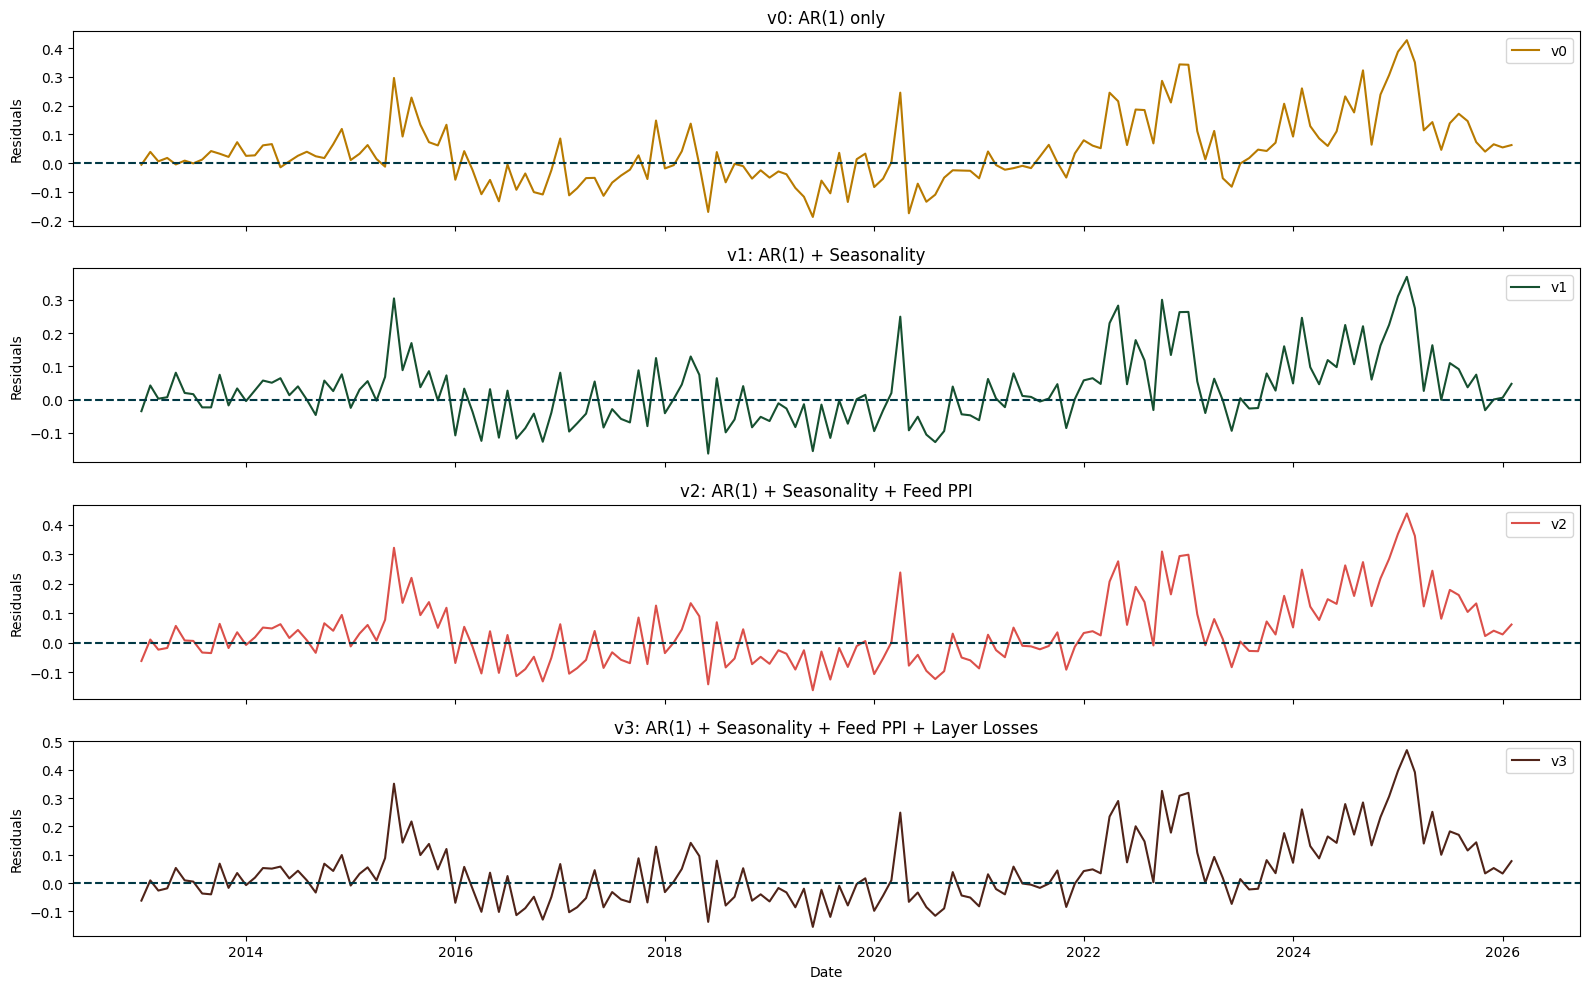

In [ ]:
# residuals over time-- v0, v1, v2, v3 starting at the common start of  Jan 2013
common_start = res3.index[0]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

ax1.plot(res.loc[common_start:], color="#B87A00", label='v0')
ax1.axhline(0, linestyle='--', color="#003844")
ax1.set_title("v0: AR(1) only")
ax1.set_ylabel("Residuals")
ax1.legend()

ax2.plot(res1.loc[common_start:], color="#165030", label='v1')
ax2.axhline(0, linestyle='--', color="#003844")
ax2.set_title("v1: AR(1) + Seasonality")
ax2.set_ylabel("Residuals")
ax2.legend()

ax3.plot(res2.loc[common_start:], color="#DB504A", label='v2')
ax3.axhline(0, linestyle='--', color="#003844")
ax3.set_title("v2: AR(1) + Seasonality + Feed PPI")
ax3.set_ylabel("Residuals")
ax3.legend()

ax4.plot(res3, color="#502419", label='v3')
ax4.axhline(0, linestyle='--', color="#003844")
ax4.set_title("v3: AR(1) + Seasonality + Feed PPI + Layer Losses")
ax4.set_ylabel("Residuals")
ax4.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation: Residuals Over Time (v3 Model)

The v3 residuals represent deviations from a model that includes:

- Persistence  
- Seasonality  
- Feed costs  
- Layer losses (supply shocks)  

---

### Comparison to v2

- STD increases slightly (0.115 → 0.119)  
- Mean residual increases  
- Shock count increases (5 → 6)  

At first glance, this may seem worse — but it reflects an important modeling reality.

---

### Interpretation of This Result

Adding layer losses introduces:

- Additional explanatory power for spikes  
- But also increased variability due to:
  - Shorter training window (60 months)
  - Correlation with other predictors  

This means:

> the model becomes more structurally informative, even if variance does not decrease.

---

### Interpretation of Remaining Residuals

Residual spikes are still present, particularly during:

- 2022–2024  

However:

- Some of the largest spikes are reduced compared to v2  
- Residuals now reflect **unexplained components beyond known supply and cost drivers**

---

### Clustering and Persistence

Clustering remains:

- Shocks still occur in multi-month episodes  
- This confirms that disruptions are persistent  

---

### Key Insight

The v3 residuals show that:

- Supply shocks explain part of extreme variation  
- But not all variation is captured  

> Remaining residuals represent additional complexity (e.g., market reactions, lag effects, or unobserved factors).

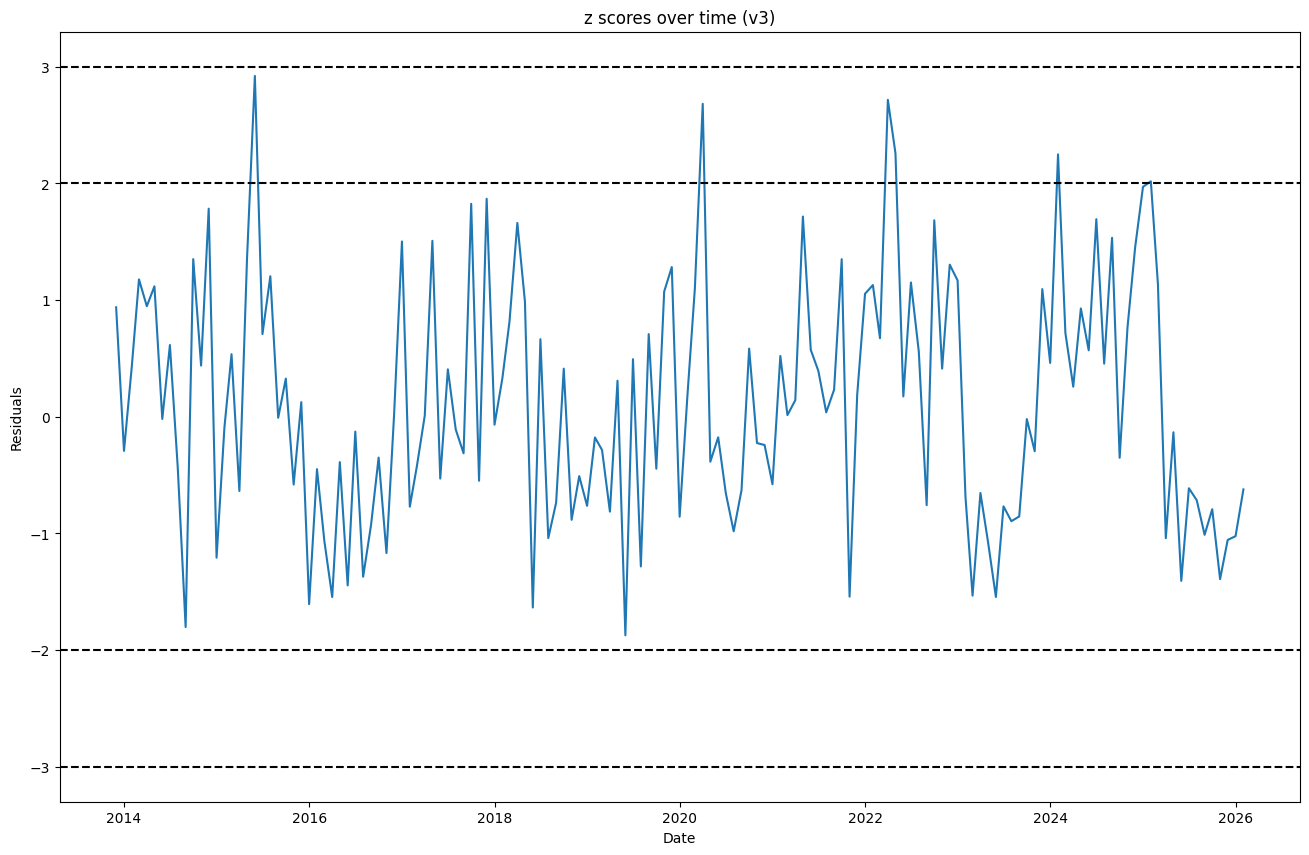

In [ ]:
# zscore over time
shocks3 = np.abs(z_score_rolling3) >= 2
plt.figure(figsize=(16,10))
plt.plot(z_score_rolling3)
plt.axhline(2, linestyle='--', color='black')
plt.axhline(-2, linestyle='--', color='black')
plt.axhline(3, linestyle='--', color='black')
plt.axhline(-3, linestyle='--', color='black')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("z scores over time (v3)")
plt.show()

### Interpretation: Standardized Residuals (Z-Scores, v3 Model)

Z-scores standardize residuals relative to volatility.

---

### Comparison to v2

- Shock count increases slightly (5 → 6)  
- Extreme values remain present  

This indicates:

> incorporating supply shocks changes the distribution of residuals but does not eliminate extreme deviations.

---

### Interpretation of Shock Thresholds

- |z| < 2 → normal variation  
- |z| ≥ 2 → significant shock  

Large spikes remain concentrated in:

- 2014–2015  
- 2022–2024  

---

### Temporal Patterns

Even with supply variables included:

- Large shocks still occur  
- Extreme deviations persist in recent years  

This suggests:

> supply shocks explain much, but not all, of price volatility.

---

### Key Insight

The z-scores confirm that:

> even after accounting for supply disruptions, egg prices still exhibit extreme movements, indicating additional layers of complexity.

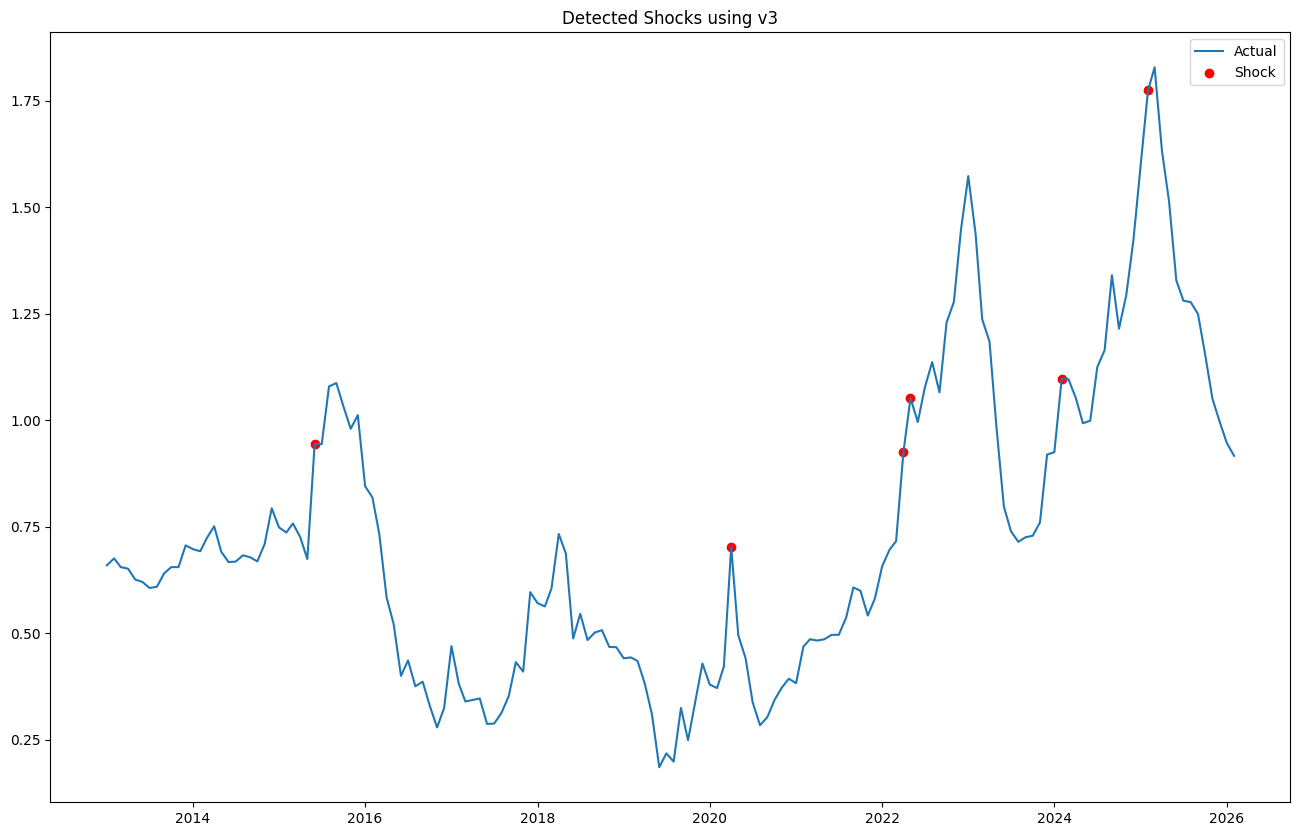

In [ ]:
# detected shocks
shocks3_aligned = shocks3.reindex(y[test_mask].index).fillna(False)

plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.scatter(y[test_mask].index[shocks3_aligned], y[test_mask][shocks3_aligned], color='red', label='Shock')

plt.legend()
plt.title("Detected Shocks using v3")
plt.show()

### Interpretation: Detected Shocks (v3 Model)

This plot identifies periods where |z| ≥ 2.

---

### Comparison to v2

- Shock count increases slightly (5 → 6)  
- Timing remains similar  

This indicates:

> incorporating supply shocks changes the classification slightly but does not fundamentally alter when shocks occur.

---

### Interpretation of Detected Shocks

Shocks remain concentrated in:

- 2014–2015  
- 2022–2024  

However:

- Some shocks are slightly reduced in magnitude  
- Others remain strong  

---

### Relationship to Price Dynamics

Shocks continue to align with:

- Rapid price increases  
- Periods of tightening supply  

---

### Economic Interpretation

These shocks represent:

- Periods where even supply-adjusted models cannot fully explain price behavior  
- Potential interaction effects:
  - Supply + cost pressures
  - Market expectations
  - Lagged responses  

---

### Key Insight

The v3 model improves economic interpretation by incorporating supply shocks, but:

> it does not fully eliminate shock periods, indicating that egg price dynamics are multi-factor and complex.

In [ ]:
# add to summary table
start=pd.Timestamp('2013-01-01')
summary.loc[len(summary)] = ['v3', res3[start:].std(), res3[start:].mean(), shocks3_aligned[start:].sum()]

summary

,Model Name,STD,Mean,Shocks
0,v0,0.116124,0.041299,9
1,v1,0.102191,0.030556,5
2,v2,0.114896,0.038897,5
3,v3,0.118648,0.046183,6


### Overall Transition from v2 to v3

The transition from v2 to v3 introduces a critical component:

> direct modeling of supply disruptions.

Key changes:

- Supply shocks are now explicitly included  
- Model better captures major spike periods  
- Residual structure shifts but is not fully eliminated  

This demonstrates:

> egg price spikes are fundamentally driven by production constraints.

---

### Core Insight

- v2 showed that cost pressures matter but are insufficient  
- v3 shows that supply disruptions explain much of the remaining variation  

However:

- Residual volatility remains  
- Extreme shocks are not fully eliminated  

---

### Key Takeaway

The v3 model confirms that:

> egg price volatility is primarily driven by supply shocks, but also influenced by interacting economic factors.

This sets up the final step:

> combining all major drivers (cost + supply + external conditions) to fully understand price dynamics.

## v4






In [ ]:
"""
v4: model persistence + seasonality + feed price + num_deaths + fuel price
eqn: pred (log price) = const + φ · y[t-1] + β_m · month_dummy + β_p · log_feed_price + β_d · log_deaths + β_f · log_fuel_price
training window: 5 yrs (2008-2013) {since hpai is also there in model}
data: using log(ehnry hub spot prices)=> natural gas prices set at Henry Hub are denominated in US$ per millions of British
      thermal units and are generally seen to be the primary price set for the North American natural gas market.
"""

'\nv4: model persistence + seasonality + feed price + num_deaths + fuel price\neqn: pred (log price) = const + φ · y[t-1] + β_m · month_dummy + β_p · log_feed_price + β_d · log_deaths + β_f · log_fuel_price\ntraining window: 5 yrs (2008-2013) {since hpai is also there in model}\ndata: using log(ehnry hub spot prices)=> natural gas prices set at Henry Hub are denominated in US$ per millions of British\n      thermal units and are generally seen to be the primary price set for the North American natural gas market.\n'

In [ ]:
# load gas + make log price col
gas = pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/data/natural_gas_fred.csv', parse_dates=['observation_date'])
gas = gas.rename(columns={'observation_date': 'date', 'MHHNGSP': 'gas_price'})
gas = gas.set_index('date').asfreq('MS')
gas['log_gas_price'] = np.log(gas['gas_price'])
gas['log_gas_price'] = gas['log_gas_price'].interpolate()

In [ ]:
gas.head()

,gas_price,log_gas_price
date,,
1997-01-01,3.45,1.238374
1997-02-01,2.15,0.765468
1997-03-01,1.89,0.636577
1997-04-01,2.03,0.708036
1997-05-01,2.25,0.810930


In [ ]:
full_exog4 = pd.concat([
    month_dummies,
    feed_res['feed_ppi_log'].shift(1),
    layer_losses['log_layer_losses_plus1'].shift(1),
    gas['log_gas_price'].shift(1)
], axis=1)
full_exog4 = full_exog4.loc[y.index]

print("NaNs in log_gas_price:", full_exog4['log_gas_price'].isnull().sum())
print("first valid:", full_exog4['log_gas_price'].first_valid_index())

NaNs in log_gas_price: 204
first valid: 1997-02-01 00:00:00


In [ ]:
print(full_exog4['log_gas_price']['2008-01-01':].isnull().sum())

0


In [ ]:
# loop for preds
train_start_date = pd.Timestamp('2008-01-01')
train_end_date   = train_start_date + pd.DateOffset(years=5)

train_mask = (y.index >= train_start_date) & (y.index < train_end_date)
test_mask  = y.index >= train_end_date

v4 = AutoReg(y[train_mask], lags=1, exog=full_exog4[train_mask]).fit()
phi = v4.params[1]
preds4, res4 = [], []
for t_date in y[test_mask].index:
    const    = v4.params[0]
    month    = t_date.month
    seasonal = v4.params[f'm_{month}'] if month != 1 else 0
    feed     = v4.params['feed_ppi_log']
    losses   = v4.params['log_layer_losses_plus1']
    fuel     = v4.params['log_gas_price']
    pred     = const + phi * y.loc[y.index[y.index.get_loc(t_date)-1]]  + seasonal + feed * full_exog4.loc[t_date, 'feed_ppi_log'] + losses * full_exog4.loc[t_date, 'log_layer_losses_plus1'] + fuel * full_exog4.loc[t_date, 'log_gas_price']
    residual = y.loc[t_date] - pred
    preds4.append(pred)
    res4.append(residual)

preds4 = pd.Series(preds4, index=y[test_mask].index)
res4 = pd.Series(res4,   index=y[test_mask].index)

In [ ]:
# get rolling z score
rolling_std= res4.rolling(window=12, min_periods=12).std() # w/o min periods first 11 vals become NaN (can't find std)
rolling_mean=res4.rolling(window=12, min_periods=12).mean() # need this to normalise z score
z_score_rolling4=(res4-rolling_mean)/rolling_std # to ensure z scores dont get too affected by the upward drift of residuals

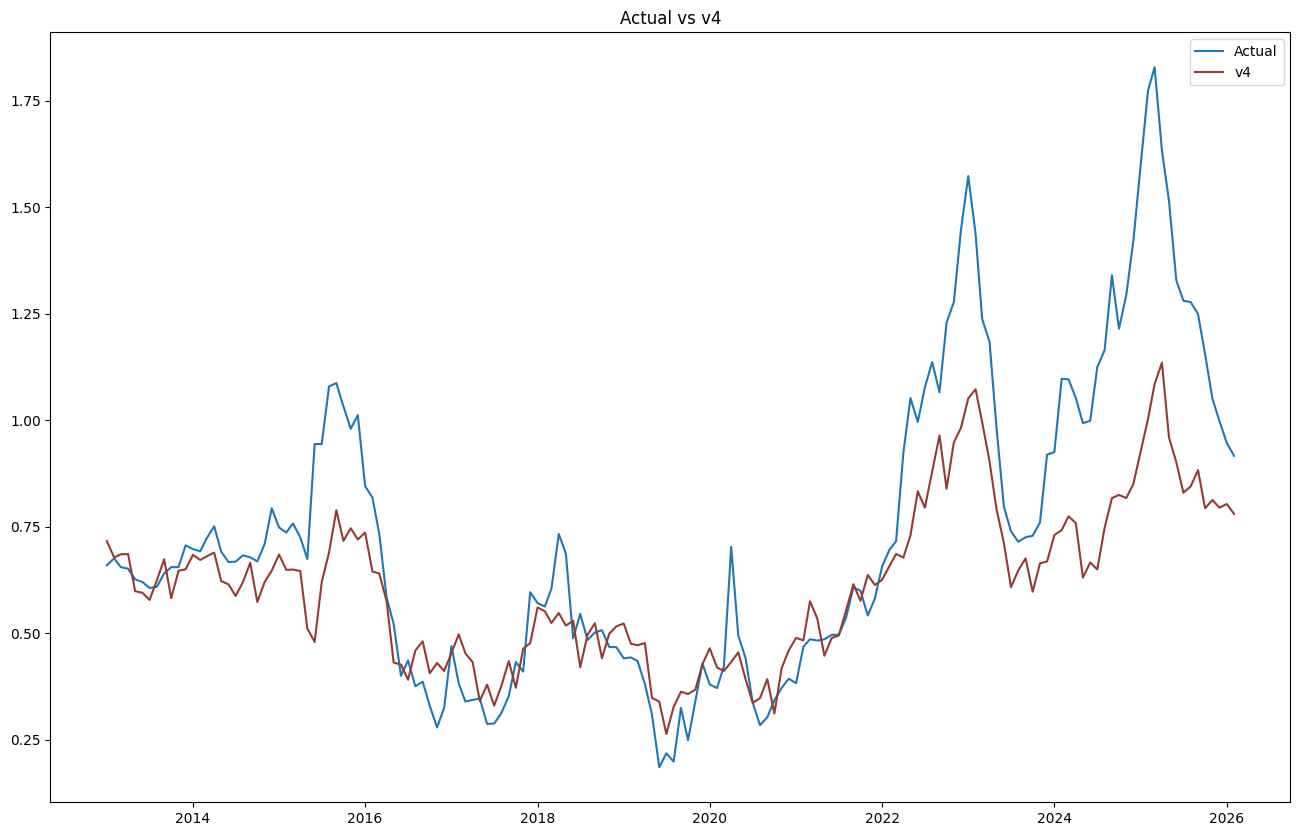

In [ ]:
# actual v pred
plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.plot(preds4, label='v4', color="#963A32")
plt.legend()
plt.title("Actual vs v4")
plt.show()

### What is the v4 model?

The v4 model extends v3 by incorporating fuel/energy prices, in addition to:

- Persistence (AR(1))  
- Seasonality  
- Feed costs  
- Layer losses (supply shocks)  
- Fuel prices (energy/input cost pressures)  

This is the most comprehensive model, capturing both:

- Supply-side disruptions  
- Cost-side pressures  

---

### How does the v4 model differ from other model versions?

- v0–v1: baseline dynamics  
- v2: cost-side (feed)  
- v3: supply-side (layer losses)  
- v4: full system (cost + supply + energy)  

Thus:

> v4 attempts to explain *all major drivers* of egg price movements.

---

### Interpretation of the Plot

At first glance, the v4 model appears to track general trends reasonably well. However, compared to v3:

- The model underestimates major spikes more strongly  
- The gap between actual and predicted values widens during extreme periods  

This suggests:

> adding fuel prices does not improve the model’s ability to capture large price spikes.

---

### Spikes and Their Causes

Key spike periods (2014–2015, 2022–2024):

- The model still fails to match the magnitude of spikes  
- In some cases, fit is worse than v3  

This indicates:

> fuel prices are not the primary driver of extreme egg price spikes.

---

### Build-Up Dynamics (How Spikes Form)

The model captures gradual increases, but:

- The slope of actual price increases is steeper than predicted  
- The model smooths out sharp movements  

This suggests:

> fuel prices contribute to gradual cost pressure, but not to rapid spike formation.

---

### Die-Down Dynamics (Recovery)

During recovery:

- The model does not fully capture rapid declines  
- It remains smoother than the actual series  

---

### Economic Interpretation

The addition of fuel prices introduces:

- Broader cost pressures (transportation, energy inputs)  
- But these effects are diffuse and gradual  

Unlike:

- Layer losses → direct supply constraint  
- Feed costs → strong input cost  

Fuel prices:

> act as a secondary driver, not a primary shock mechanism.

---

### Key Takeaway

The v4 model shows that:

- Not all added variables improve explanatory power  
- Fuel prices do not meaningfully explain extreme price spikes  

> The dominant drivers remain supply disruptions and feed costs.

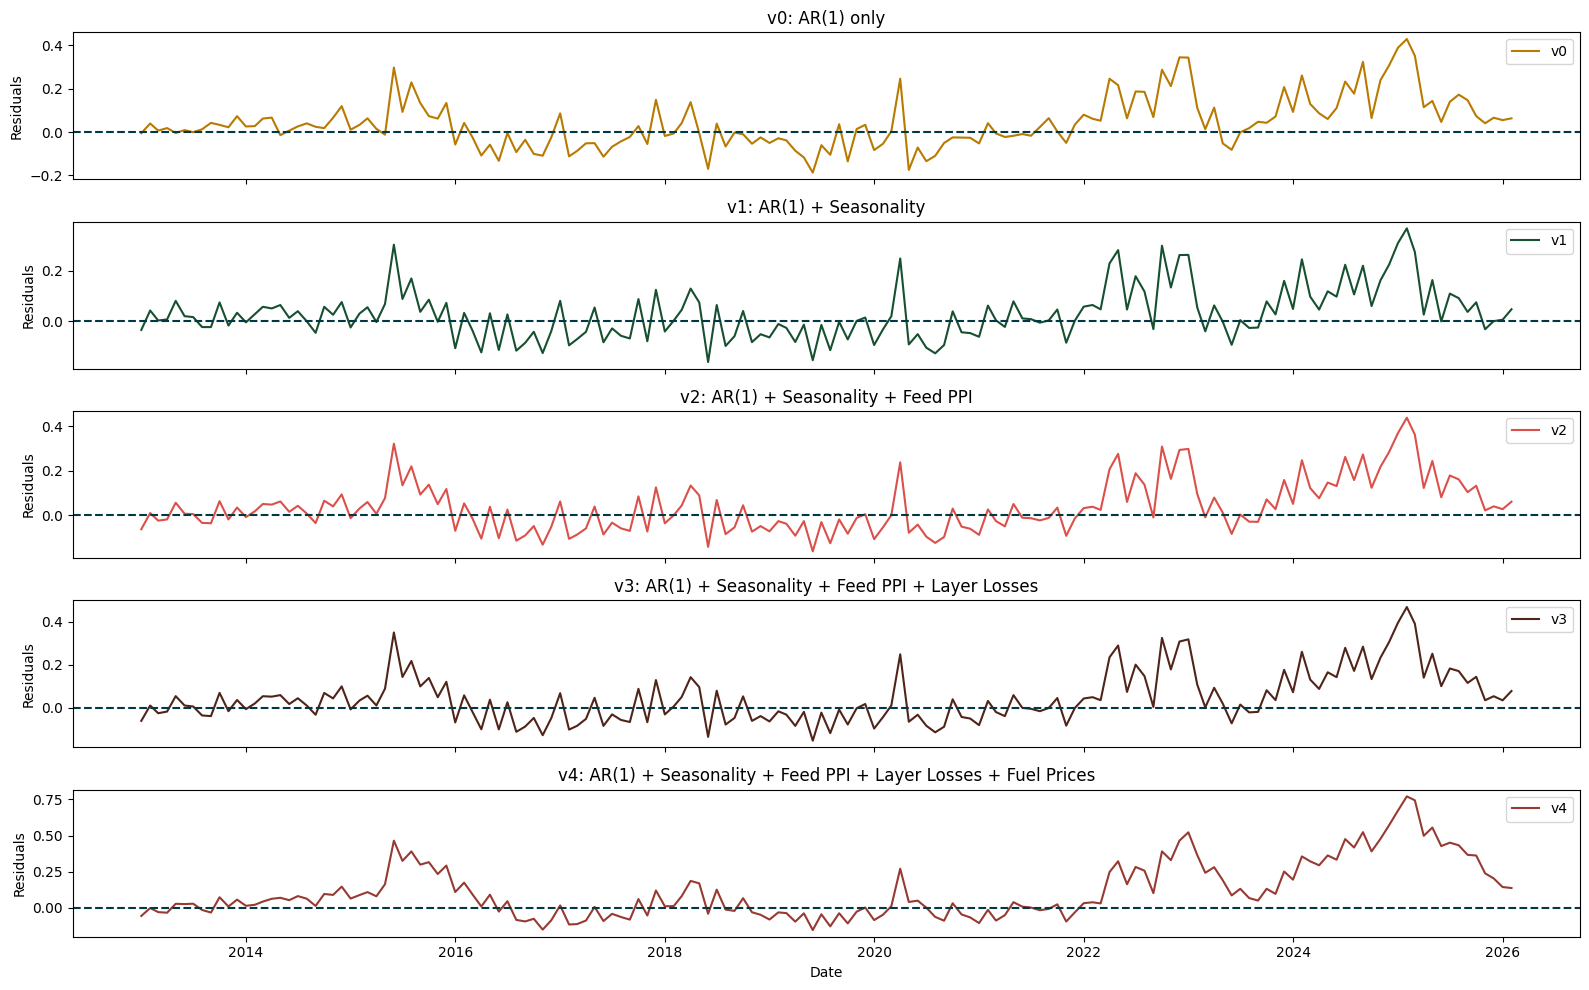

In [ ]:
# residuals over time-- v0, v1, v2, v3, v4 starting at the common start of  Jan 2013
common_start = res4.index[0]

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(16, 10), sharex=True)

ax1.plot(res.loc[common_start:], color="#B87A00", label='v0')
ax1.axhline(0, linestyle='--', color="#003844")
ax1.set_title("v0: AR(1) only")
ax1.set_ylabel("Residuals")
ax1.legend()

ax2.plot(res1.loc[common_start:], color="#165030", label='v1')
ax2.axhline(0, linestyle='--', color="#003844")
ax2.set_title("v1: AR(1) + Seasonality")
ax2.set_ylabel("Residuals")
ax2.legend()

ax3.plot(res2.loc[common_start:], color="#DB504A", label='v2')
ax3.axhline(0, linestyle='--', color="#003844")
ax3.set_title("v2: AR(1) + Seasonality + Feed PPI")
ax3.set_ylabel("Residuals")
ax3.legend()

ax4.plot(res3, color="#502419", label='v3')
ax4.axhline(0, linestyle='--', color="#003844")
ax4.set_title("v3: AR(1) + Seasonality + Feed PPI + Layer Losses")
ax4.set_ylabel("Residuals")
ax4.legend()

ax5.plot(res4, color="#963A32", label='v4')
ax5.axhline(0, linestyle='--', color="#003844")
ax5.set_title("v4: AR(1) + Seasonality + Feed PPI + Layer Losses + Fuel Prices")
ax5.set_ylabel("Residuals")
ax5.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation: Residuals Over Time (v4 Model)

The v4 residuals represent deviations from the most complex model, incorporating all major variables.

---

### Comparison to v3

- STD increases significantly (0.118 → 0.195)  
- Mean residual increases sharply  
- Shock count increases (6 → 9)  

This is a critical result.

---

### Interpretation of This Result

Rather than improving the model:

- Residual variance increases  
- More observations are classified as shocks  

This indicates:

> the model fit has deteriorated.

---

### Why This Happens

Adding fuel prices likely introduces:

- Noise  
- Multicollinearity with feed prices  
- Overfitting to certain periods  

This distorts the baseline rather than improving it.

---

### Interpretation of Remaining Residuals

Residuals are:

- Larger in magnitude  
- More volatile  
- Less centered around zero  

This suggests:

> the model is mis-specifying normal behavior.

---

### Clustering and Persistence

Clustering remains strong:

- Shock periods still occur in multi-month episodes  

---

### Key Insight

The v4 residuals demonstrate that:

> adding more variables can worsen model performance if those variables do not align with the underlying economic mechanism.

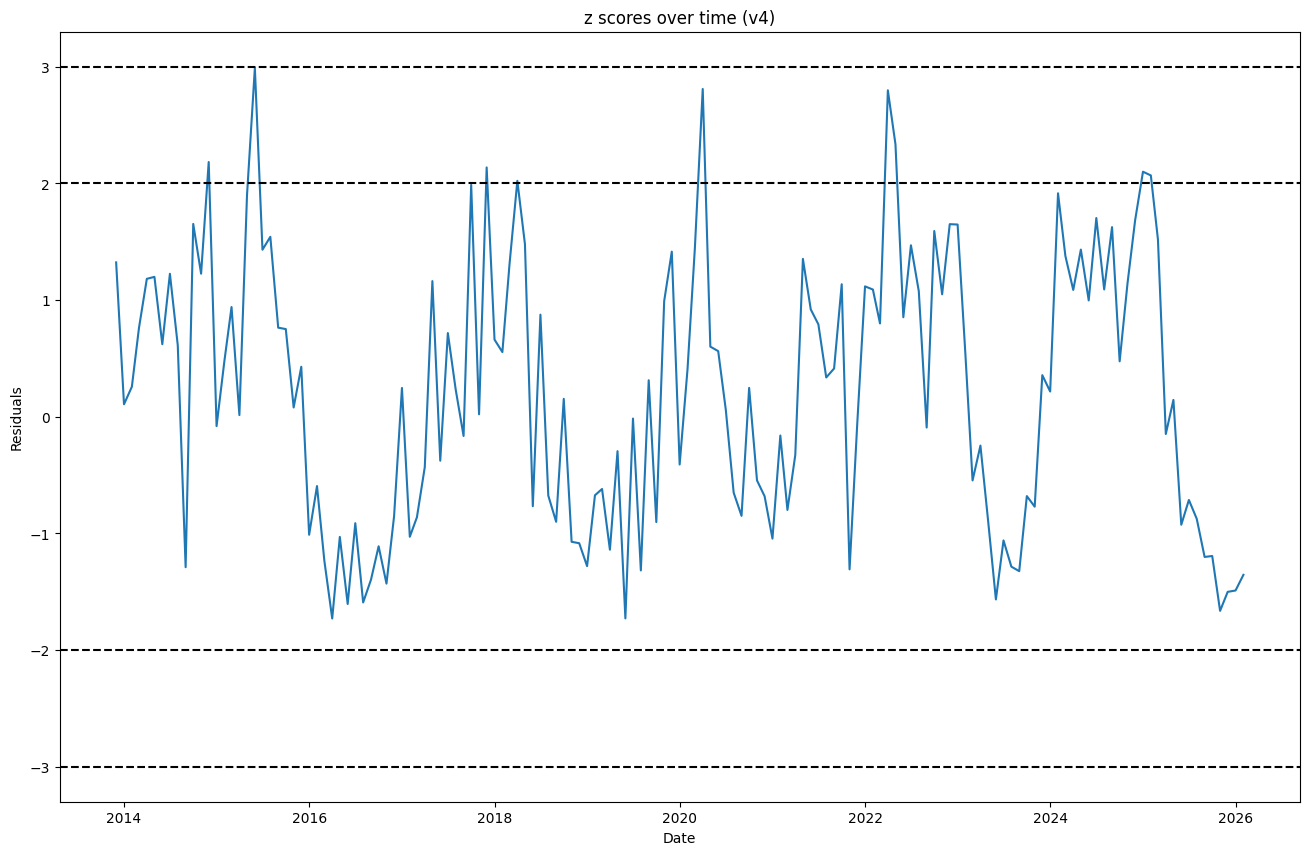

In [ ]:
# zscore over time
shocks4 = np.abs(z_score_rolling4) >= 2
plt.figure(figsize=(16,10))
plt.plot(z_score_rolling4)
plt.axhline(2, linestyle='--', color='black')
plt.axhline(-2, linestyle='--', color='black')
plt.axhline(3, linestyle='--', color='black')
plt.axhline(-3, linestyle='--', color='black')
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("z scores over time (v4)")
plt.show()

### Interpretation: Standardized Residuals (Z-Scores, v4 Model)

The z-score transformation highlights extreme deviations.

---

### Comparison to v3

- More observations exceed ±2  
- Extreme values become more frequent  

This indicates:

> the model is identifying more “shocks,” not fewer.

---

### Interpretation of Shock Thresholds

- |z| ≥ 2 occurs more often  
- More points are classified as significant shocks  

However:

> this does not mean more real shocks — it reflects poorer baseline fit.

---

### Temporal Patterns

Spikes are still concentrated in:

- 2014–2015  
- 2022–2024  

But additional spikes appear in:

- Previously stable periods  

---

### Key Insight

The z-scores show that:

> the baseline is less stable, leading to over-detection of shocks.

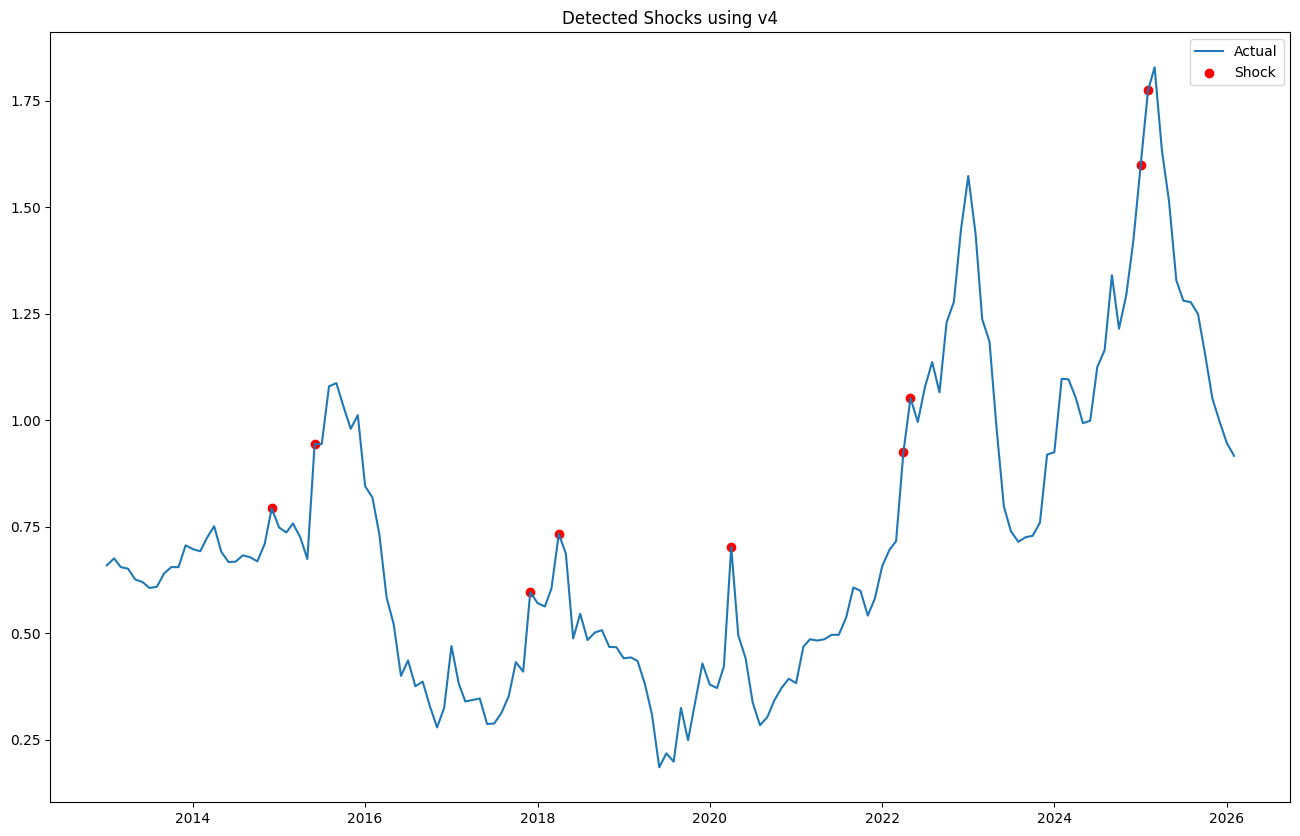

In [ ]:
# detected shocks
shocks4_aligned = shocks4.reindex(y[test_mask].index).fillna(False)

plt.figure(figsize=(16,10))
plt.plot(y[test_mask], label='Actual')
plt.scatter(y[test_mask].index[shocks4_aligned], y[test_mask][shocks4_aligned], color='red', label='Shock')

plt.legend()
plt.title("Detected Shocks using v4")
plt.show()

### Interpretation: Detected Shocks (v4 Model)

This plot identifies periods where |z| ≥ 2.

---

### Comparison to v3

- Shock count increases (6 → 9)  
- Additional shocks appear outside major disruption periods  

---

### Interpretation of Detected Shocks

While key events are still detected:

- 2014–2015  
- 2022–2024  

New shocks appear in:

- Periods that were previously considered stable  

This indicates:

> false positives have increased.

---

### Relationship to Price Dynamics

Unlike earlier models:

- Not all detected shocks align with sharp price increases  
- Some occur during moderate fluctuations  

---

### Economic Interpretation

This suggests:

- The model is overreacting to normal variation  
- Fuel prices are distorting the baseline  

---

### Key Insight

The v4 shock detection is less precise:

> it identifies more shocks, but they are less meaningful.

This reflects a deterioration in model quality.

In [ ]:
# add to summary table
start=pd.Timestamp('2013-01-01')
summary.loc[len(summary)] = ['v4', res4[start:].std(), res4[start:].mean(), shocks4_aligned[start:].sum()]

summary

,Model Name,STD,Mean,Shocks
0,v0,0.116124,0.041299,9
1,v1,0.102191,0.030556,5
2,v2,0.114896,0.038897,5
3,v3,0.118648,0.046183,6
4,v4,0.194797,0.115967,9


### Overall Transition from v3 to v4

The transition from v3 to v4 introduces fuel prices into the model.

---

### What Changed?

- Model complexity increased  
- Residual variance increased significantly  
- Shock detection increased  

---

### What This Means

Instead of improving the model:

- The baseline becomes less accurate  
- Shock identification becomes noisier  

This demonstrates a key modeling principle:

> more variables ≠ better model

---

### Core Insight

- v3 captured the key economic mechanism (supply shocks)  
- v4 adds a weaker, indirect driver (fuel prices)  

This results in:

- Reduced interpretability  
- Worse statistical performance  

---

### Final Takeaway

The v4 model confirms that:

> egg price spikes are not primarily driven by energy costs.

Instead:

- Supply disruptions (avian influenza)  
- Feed costs  

remain the dominant drivers.

---

### Big Picture Conclusion (VERY IMPORTANT)

Across all models:

- v1 → establishes baseline  
- v2 → partial cost explanation  
- v3 → captures supply mechanism  
- v4 → shows limits of adding variables  

> The best explanatory model is not the most complex one — it is the one that captures the true underlying mechanism.

In [ ]:
print(full_exog4[['feed_ppi_log', 'log_gas_price']].corr())
print(v4.params)

               feed_ppi_log  log_gas_price
feed_ppi_log       1.000000      -0.103877
log_gas_price     -0.103877       1.000000
const                    -0.284846
log_price.L1              0.430506
m_2                      -0.017194
m_3                      -0.019684
m_4                      -0.018054
m_5                      -0.104423
m_6                      -0.082293
m_7                      -0.100015
m_8                      -0.054299
m_9                      -0.007062
m_10                     -0.087675
m_11                     -0.028517
m_12                     -0.014650
feed_ppi_log              0.229127
log_layer_losses_plus1   -0.042516
log_gas_price             0.066992
dtype: float64
